# Business Problem

# import libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.style
from warnings import filterwarnings
filterwarnings('ignore')

# read data set

In [3]:
df = pd.read_csv('supply_train.csv')

In [4]:
df.head()

,Unnamed: 0,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,...,1,112,25.0,2009.0,18,0,C,6,24,24071


In [5]:
# to drop first column
df.drop('Unnamed: 0',axis=1,inplace=True)

In [6]:
pd.options.display.max_columns = None
df.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,Rented,24,0,1,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,Company Owned,47,0,0,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,Company Owned,64,0,0,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,Rented,50,0,0,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,Company Owned,42,1,0,1,112,25.0,2009.0,18,0,C,6,24,24071


In [7]:
df.shape

(16620, 24)

In [8]:
df.columns

Index(['Ware_house_ID', 'WH_Manager_ID', 'Location_type', 'WH_capacity_size',
       'zone', 'WH_regional_zone', 'num_refill_req_l3m', 'transport_issue_l1y',
       'Competitor_in_mkt', 'retail_shop_num', 'wh_owner_type',
       'distributor_num', 'flood_impacted', 'flood_proof', 'electric_supply',
       'dist_from_hub', 'workers_num', 'wh_est_year',
       'storage_issue_reported_l3m', 'temp_reg_mach',
       'approved_wh_govt_certificate', 'wh_breakdown_l3m', 'govt_check_l3m',
       'product_wg_ton'],
      dtype='object')

# Descriptive Details

In [9]:
df.describe()

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
count,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,15953.000000,8760.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000
mean,4.126655,0.780927,3.103129,4983.904994,42.473706,0.096871,0.056017,0.655716,163.521901,28.911490,2009.345320,17.127196,0.306137,3.491095,18.727377,22098.420096
std,2.606241,1.206351,1.147711,1051.032239,16.090000,0.295791,0.229961,0.475149,62.701193,7.842046,7.544672,9.163901,0.460901,1.688614,8.619857,11620.337346
min,0.000000,0.000000,0.000000,1821.000000,15.000000,0.000000,0.000000,0.000000,55.000000,10.000000,1996.000000,0.000000,0.000000,0.000000,1.000000,2093.000000
25%,2.000000,0.000000,2.000000,4309.000000,29.000000,0.000000,0.000000,0.000000,109.000000,24.000000,2003.000000,10.000000,0.000000,2.000000,11.000000,13057.000000
50%,4.000000,0.000000,3.000000,4856.000000,42.000000,0.000000,0.000000,1.000000,164.000000,28.000000,2009.000000,18.000000,0.000000,3.000000,19.000000,22099.000000
75%,6.000000,1.000000,4.000000,5500.000000,56.000000,0.000000,0.000000,1.000000,218.000000,33.000000,2016.000000,24.000000,1.000000,5.000000,26.000000,30103.000000
max,8.000000,5.000000,12.000000,11008.000000,70.000000,1.000000,1.000000,1.000000,271.000000,98.000000,2023.000000,39.000000,1.000000,6.000000,32.000000,55151.000000


# understanding of attributes

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16620 entries, 0 to 16619
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 16620 non-null  object 
 1   WH_Manager_ID                 16620 non-null  object 
 2   Location_type                 16620 non-null  object 
 3   WH_capacity_size              16620 non-null  object 
 4   zone                          16620 non-null  object 
 5   WH_regional_zone              16620 non-null  object 
 6   num_refill_req_l3m            16620 non-null  int64  
 7   transport_issue_l1y           16620 non-null  int64  
 8   Competitor_in_mkt             16620 non-null  int64  
 9   retail_shop_num               16620 non-null  int64  
 10  wh_owner_type                 16620 non-null  object 
 11  distributor_num               16620 non-null  int64  
 12  flood_impacted                16620 non-null  int64  
 13  f

# EDA

## unique values

In [11]:
df.WH_Manager_ID.nunique()

16620

In [12]:
df.drop(['Ware_house_ID','WH_Manager_ID'],axis=1,inplace=True)

In [13]:
df.head()

,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,Urban,Small,West,Zone 6,3,1,2,4651,Rented,24,0,1,1,91,29.0,NaN,13,0,A,5,15,17115
1,Rural,Large,North,Zone 5,0,0,4,6217,Company Owned,47,0,0,1,210,31.0,NaN,4,0,A,3,17,5074
2,Rural,Mid,South,Zone 2,1,0,4,4306,Company Owned,64,0,0,0,161,37.0,NaN,17,0,A,6,22,23137
3,Rural,Mid,North,Zone 3,7,4,2,6000,Rented,50,0,0,0,103,21.0,NaN,17,1,A+,3,27,22115
4,Rural,Large,North,Zone 5,3,1,2,4740,Company Owned,42,1,0,1,112,25.0,2009.0,18,0,C,6,24,24071


# missing values

In [14]:
len(df)

16620

In [15]:
df.isnull().sum()*100/len(df) #null values % aayi kittan

Location_type                    0.000000
WH_capacity_size                 0.000000
zone                             0.000000
WH_regional_zone                 0.000000
num_refill_req_l3m               0.000000
transport_issue_l1y              0.000000
Competitor_in_mkt                0.000000
retail_shop_num                  0.000000
wh_owner_type                    0.000000
distributor_num                  0.000000
flood_impacted                   0.000000
flood_proof                      0.000000
electric_supply                  0.000000
dist_from_hub                    0.000000
workers_num                      4.013237
wh_est_year                     47.292419
storage_issue_reported_l3m       0.000000
temp_reg_mach                    0.000000
approved_wh_govt_certificate     3.604091
wh_breakdown_l3m                 0.000000
govt_check_l3m                   0.000000
product_wg_ton                   0.000000
dtype: float64

In [16]:
df['approved_wh_govt_certificate'].mode()

0    C
Name: approved_wh_govt_certificate, dtype: object

In [17]:
# we can drop the warehous estimated feature as there is 47% missing data and there is no need to predict dependent variales
df.drop(['wh_est_year'],axis=1, inplace=True)

In [18]:
# the missing value in 'approved_wh_govt_certificate' are low so we can use mode value to fill as it is a categorical values.
df.approved_wh_govt_certificate.fillna(df.approved_wh_govt_certificate.mode()[0],inplace = True)

In [19]:
# missing value in 'workers_num' is low. so we can use 'mean' values to fill as it is a numerical value
df.workers_num.fillna(df.workers_num.mean(),inplace=True)

In [20]:
# now the missing values completely eradicated(remove)
df.isnull().sum()*100/len(df)

Location_type                   0.0
WH_capacity_size                0.0
zone                            0.0
WH_regional_zone                0.0
num_refill_req_l3m              0.0
transport_issue_l1y             0.0
Competitor_in_mkt               0.0
retail_shop_num                 0.0
wh_owner_type                   0.0
distributor_num                 0.0
flood_impacted                  0.0
flood_proof                     0.0
electric_supply                 0.0
dist_from_hub                   0.0
workers_num                     0.0
storage_issue_reported_l3m      0.0
temp_reg_mach                   0.0
approved_wh_govt_certificate    0.0
wh_breakdown_l3m                0.0
govt_check_l3m                  0.0
product_wg_ton                  0.0
dtype: float64

# duplicate values

In [21]:
df.duplicated().sum()

np.int64(0)

# variable transformation: converting datatypes

In [22]:
before = df.dtypes
before

Location_type                    object
WH_capacity_size                 object
zone                             object
WH_regional_zone                 object
num_refill_req_l3m                int64
transport_issue_l1y               int64
Competitor_in_mkt                 int64
retail_shop_num                   int64
wh_owner_type                    object
distributor_num                   int64
flood_impacted                    int64
flood_proof                       int64
electric_supply                   int64
dist_from_hub                     int64
workers_num                     float64
storage_issue_reported_l3m        int64
temp_reg_mach                     int64
approved_wh_govt_certificate     object
wh_breakdown_l3m                  int64
govt_check_l3m                    int64
product_wg_ton                    int64
dtype: object

In [23]:
# converting dtypes using astype
df['Location_type'] = df['Location_type'].astype('category')
df['WH_capacity_size'] = df['WH_capacity_size'].astype('category')
df['zone'] = df['zone'].astype('category')
df['WH_regional_zone'] = df['WH_regional_zone'].astype('category')
df['wh_owner_type'] = df['wh_owner_type'].astype('category')
df['approved_wh_govt_certificate'] = df['approved_wh_govt_certificate'].astype('category')

In [24]:
after = df.dtypes
after

Location_type                   category
WH_capacity_size                category
zone                            category
WH_regional_zone                category
num_refill_req_l3m                 int64
transport_issue_l1y                int64
Competitor_in_mkt                  int64
retail_shop_num                    int64
wh_owner_type                   category
distributor_num                    int64
flood_impacted                     int64
flood_proof                        int64
electric_supply                    int64
dist_from_hub                      int64
workers_num                      float64
storage_issue_reported_l3m         int64
temp_reg_mach                      int64
approved_wh_govt_certificate    category
wh_breakdown_l3m                   int64
govt_check_l3m                     int64
product_wg_ton                     int64
dtype: object

# Univariate Analysis

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16620 entries, 0 to 16619
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Location_type                 16620 non-null  category
 1   WH_capacity_size              16620 non-null  category
 2   zone                          16620 non-null  category
 3   WH_regional_zone              16620 non-null  category
 4   num_refill_req_l3m            16620 non-null  int64   
 5   transport_issue_l1y           16620 non-null  int64   
 6   Competitor_in_mkt             16620 non-null  int64   
 7   retail_shop_num               16620 non-null  int64   
 8   wh_owner_type                 16620 non-null  category
 9   distributor_num               16620 non-null  int64   
 10  flood_impacted                16620 non-null  int64   
 11  flood_proof                   16620 non-null  int64   
 12  electric_supply               16620 non-null  

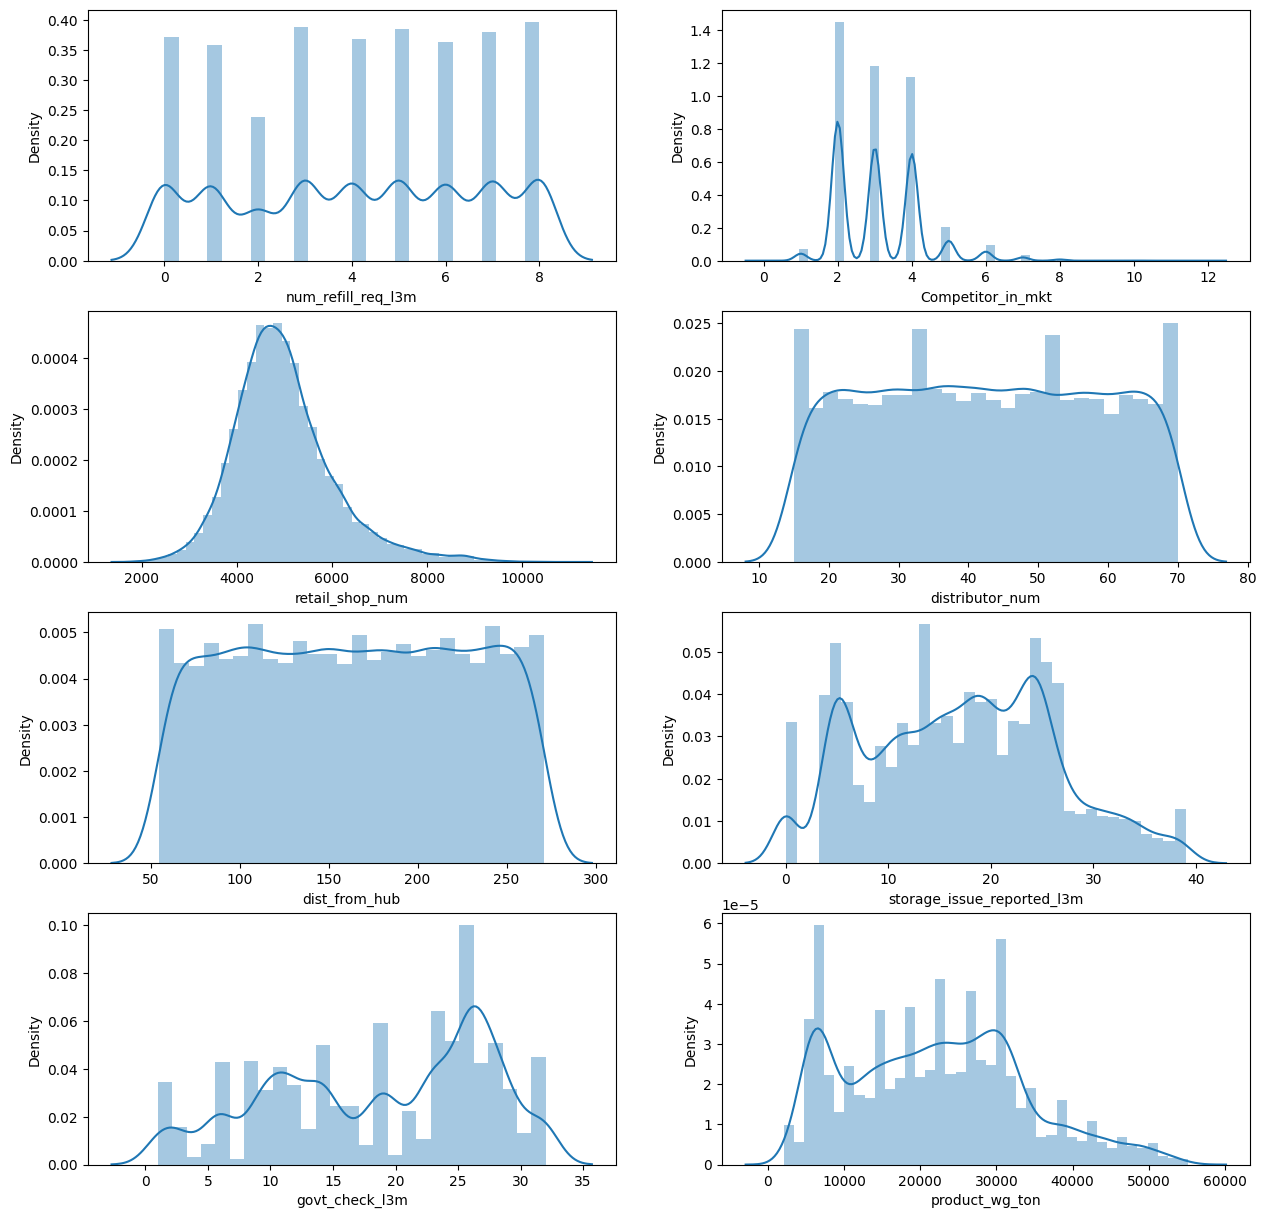

In [26]:
# check numerical values
fig,axes = plt.subplots(nrows=4,ncols=2)
fig.set_size_inches(15,15)
sns.distplot(df['num_refill_req_l3m'],kde=True, ax=axes[0][0])
sns.distplot(df['Competitor_in_mkt'],kde=True, ax=axes[0][1])
sns.distplot(df['retail_shop_num'],kde=True, ax=axes[1][0])
sns.distplot(df['distributor_num'],kde=True, ax=axes[1][1])
sns.distplot(df['dist_from_hub'],kde=True, ax=axes[2][0])
sns.distplot(df['storage_issue_reported_l3m'],kde=True, ax=axes[2][1])
sns.distplot(df['govt_check_l3m'],kde=True, ax=axes[3][0])
sns.distplot(df['product_wg_ton'],kde=True, ax=axes[3][1])
plt.show()

<Axes: xlabel='workers_num', ylabel='Density'>

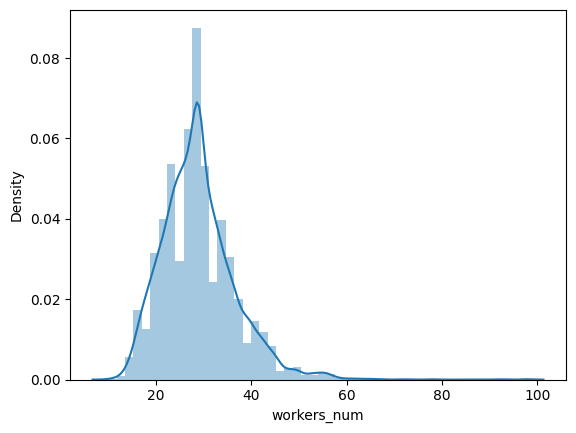

In [130]:
sns.distplot(df['workers_num'],kde=True)

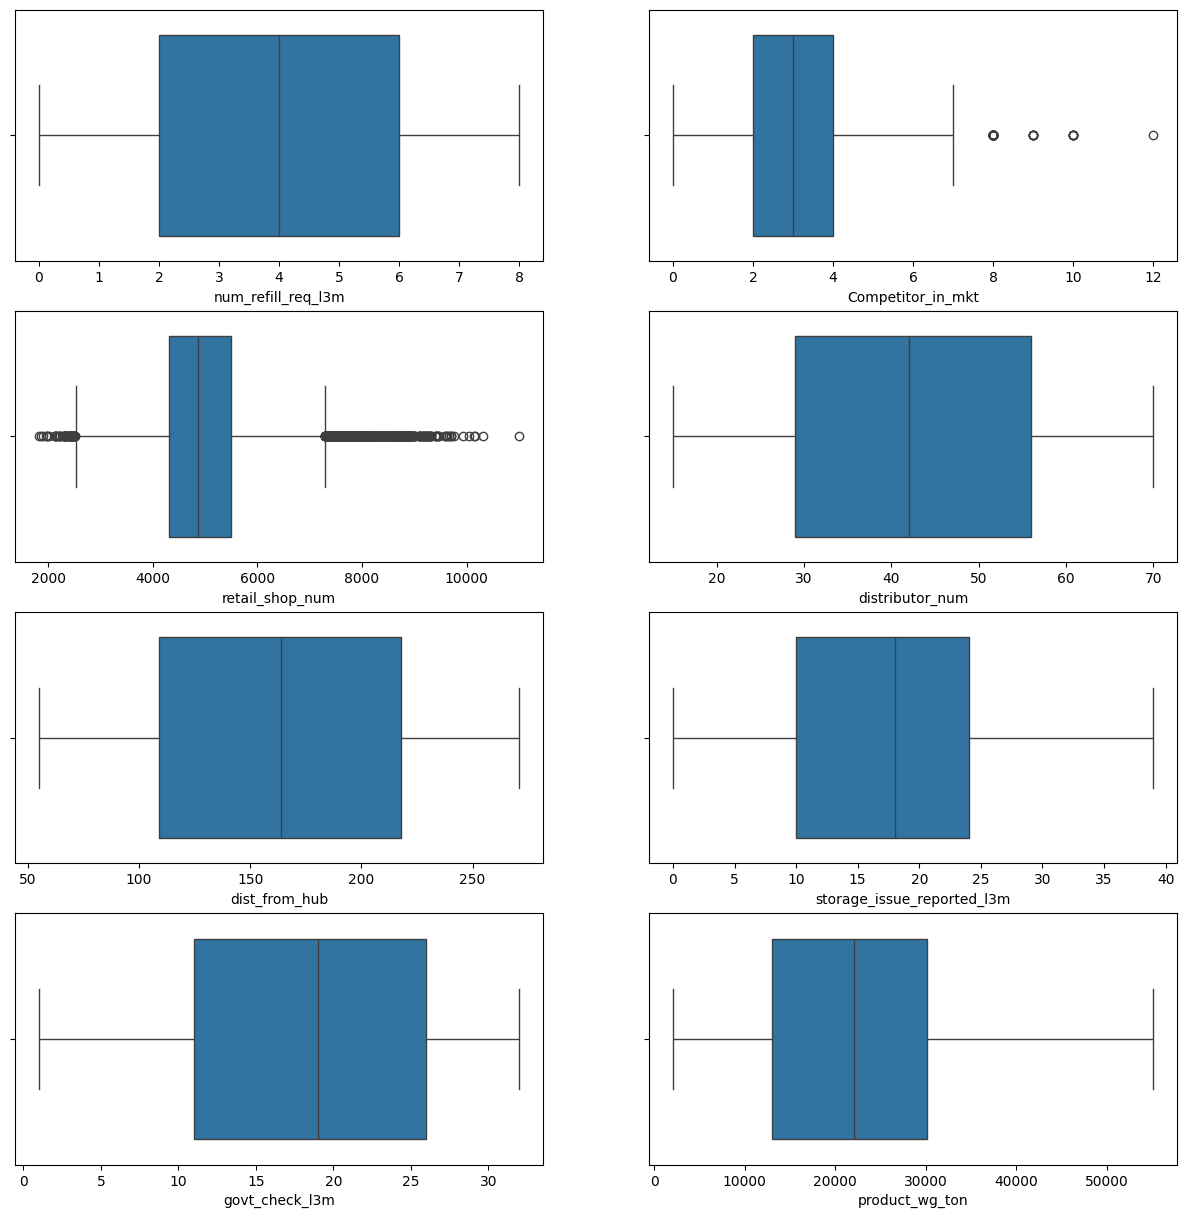

In [28]:
fig,axes = plt.subplots(nrows=4,ncols=2)
fig.set_size_inches(15,15)
sns.boxplot(x='num_refill_req_l3m',data=df, ax=axes[0][0])
sns.boxplot(x='Competitor_in_mkt',data=df, ax=axes[0][1])
sns.boxplot(x='retail_shop_num',data=df, ax=axes[1][0])
sns.boxplot(x='distributor_num',data=df, ax=axes[1][1])
sns.boxplot(x='dist_from_hub',data=df, ax=axes[2][0])
sns.boxplot(x='storage_issue_reported_l3m',data=df, ax=axes[2][1])
sns.boxplot(x='govt_check_l3m',data=df, ax=axes[3][0])
sns.boxplot(x='product_wg_ton',data=df, ax=axes[3][1])
plt.show()

<Axes: xlabel='workers_num'>

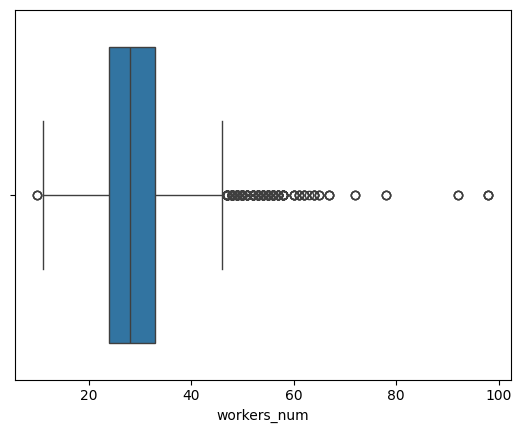

In [29]:
sns.boxplot(x='workers_num',data=df)

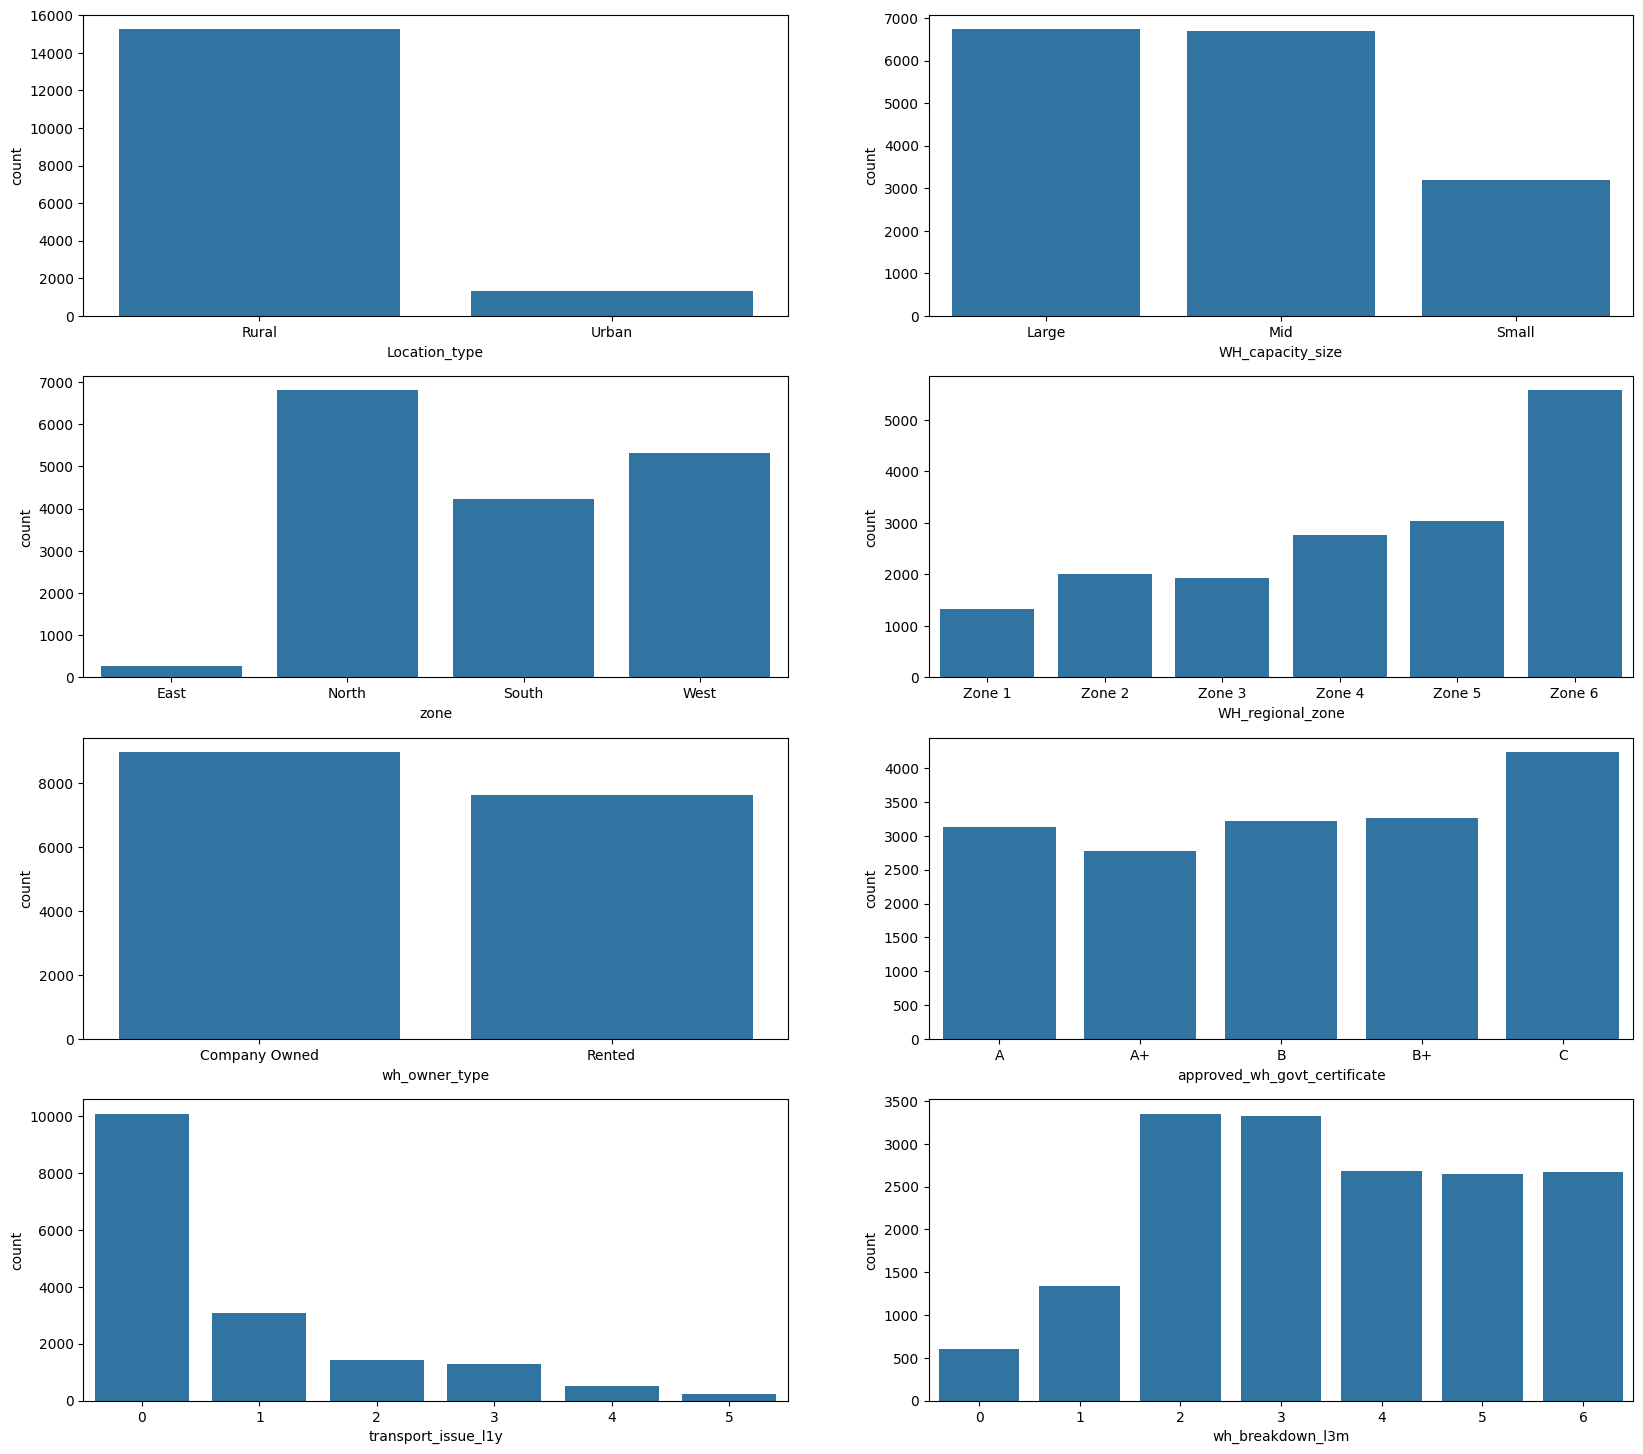

In [30]:
fig,axes = plt.subplots(nrows=4,ncols=2)
fig.set_size_inches(20,18)
sns.countplot(x='Location_type',data=df, ax=axes[0][0])
sns.countplot(x='WH_capacity_size',data=df, ax=axes[0][1])
sns.countplot(x='zone',data=df, ax=axes[1][0])
sns.countplot(x='WH_regional_zone',data=df, ax=axes[1][1])
sns.countplot(x='wh_owner_type',data=df, ax=axes[2][0])
sns.countplot(x='approved_wh_govt_certificate',data=df, ax=axes[2][1])
sns.countplot(x='transport_issue_l1y',data=df, ax=axes[3][0])
sns.countplot(x='wh_breakdown_l3m',data=df, ax=axes[3][1])
plt.show()

# Bivariate analysis

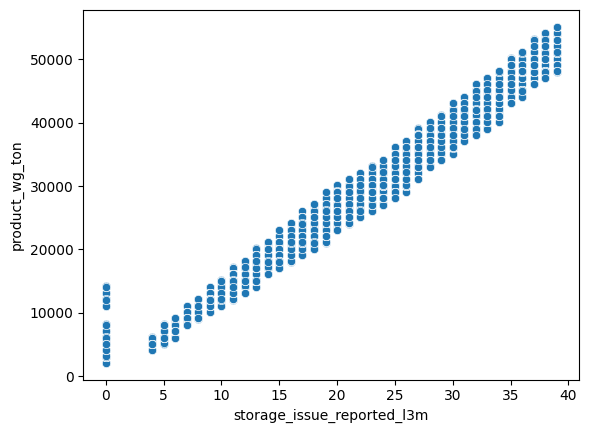

In [31]:
sns.scatterplot(x='storage_issue_reported_l3m', y='product_wg_ton', data=df)
plt.show()

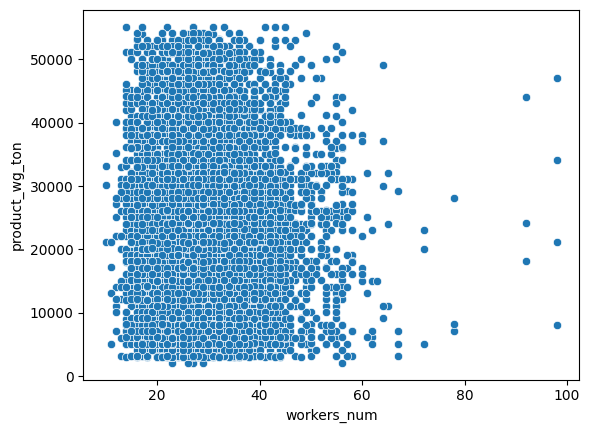

In [32]:
sns.scatterplot(x='workers_num',y='product_wg_ton', data=df)
plt.show()

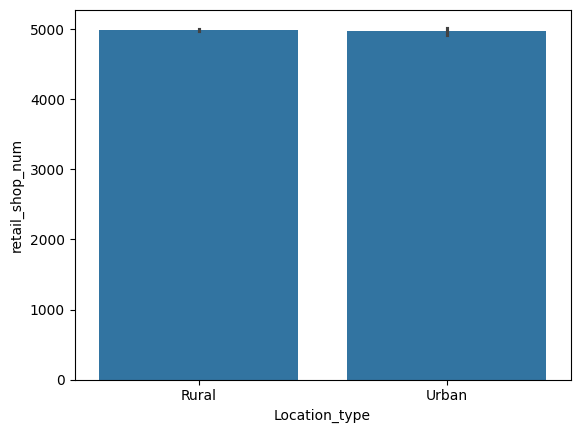

In [33]:
sns.barplot(x='Location_type', y='retail_shop_num', data=df)
plt.show()

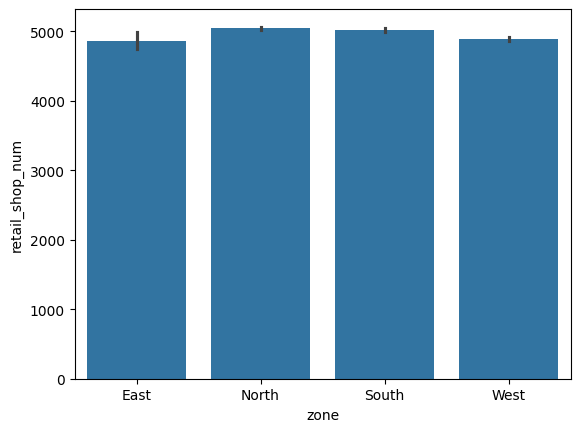

In [34]:
sns.barplot(x='zone', y='retail_shop_num', data=df)
plt.show()

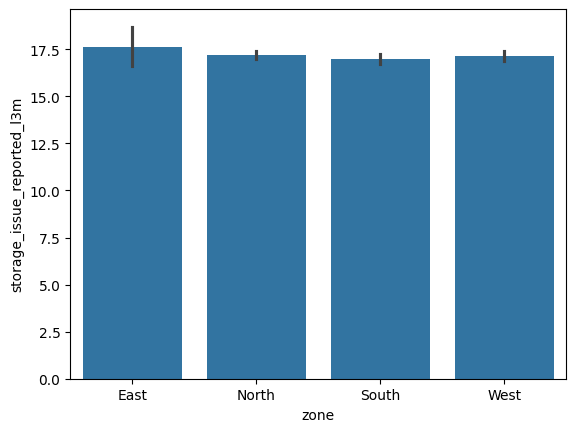

In [35]:
sns.barplot(x='zone', y='storage_issue_reported_l3m', data=df)
plt.show()

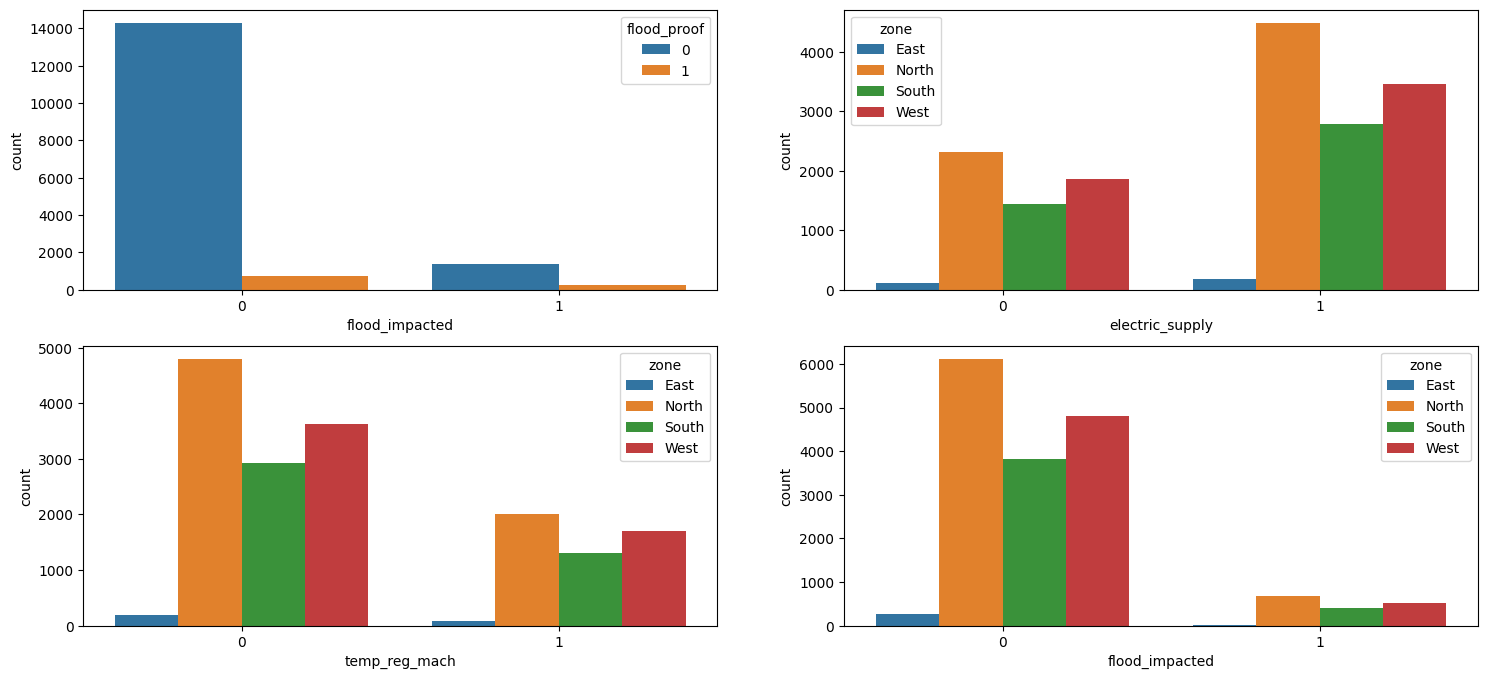

In [36]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(18,8)
sns.countplot(x='flood_impacted',hue='flood_proof',data=df,ax=axes[0][0])
sns.countplot(x='electric_supply',hue='zone',data=df,ax=axes[0][1])
sns.countplot(x='temp_reg_mach',hue='zone',data=df,ax=axes[1][0])
sns.countplot(x='flood_impacted',hue='zone',data=df,ax=axes[1][1])
plt.show()

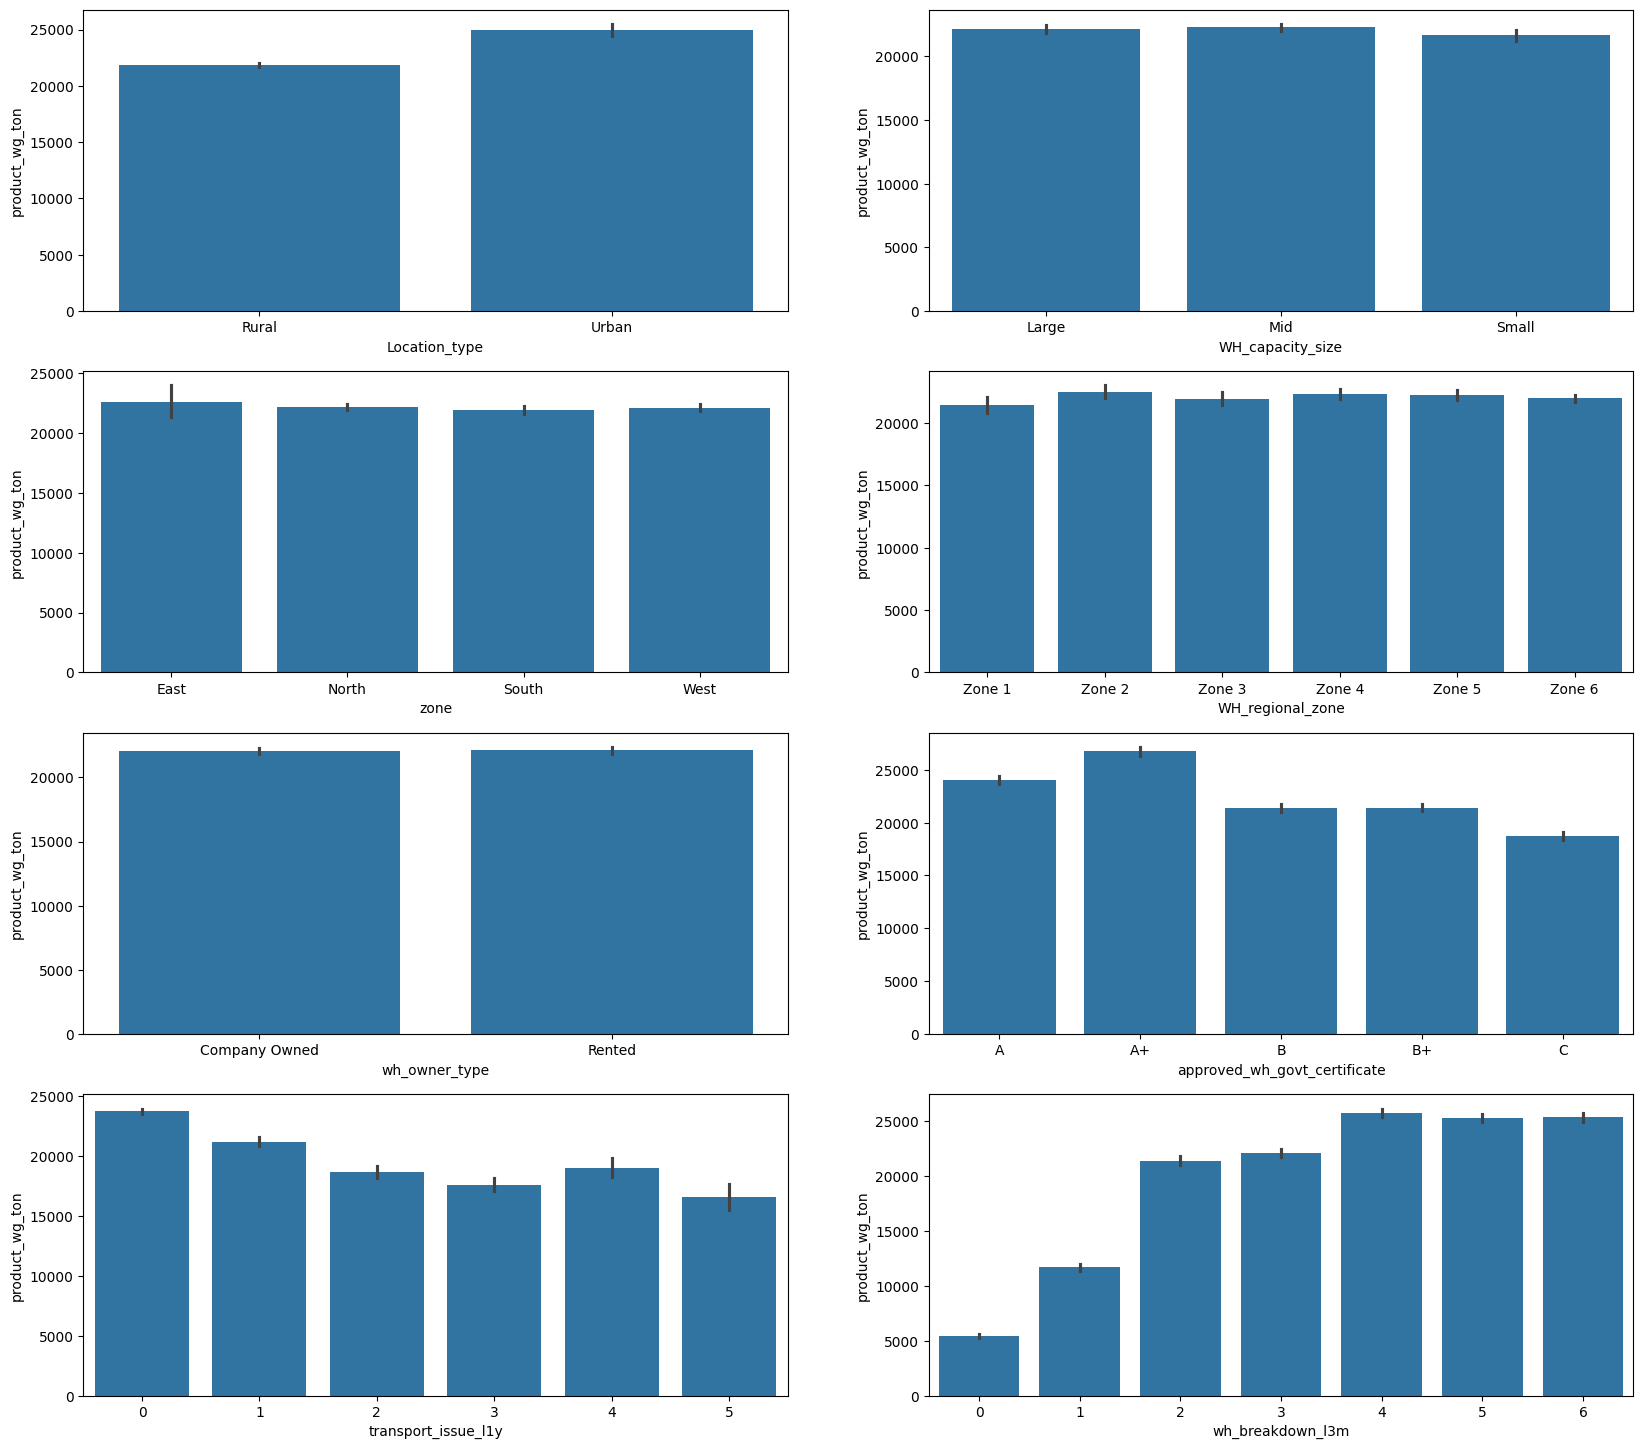

In [37]:
fig, axes = plt.subplots(nrows=4,ncols=2)
fig.set_size_inches(20,18)
sns.barplot(x='Location_type',y='product_wg_ton',data=df,ax=axes[0][0])
sns.barplot(x='WH_capacity_size',y='product_wg_ton',data=df,ax=axes[0][1])
sns.barplot(x='zone',y='product_wg_ton',data=df,ax=axes[1][0])
sns.barplot(x='WH_regional_zone',y='product_wg_ton',data=df,ax=axes[1][1])
sns.barplot(x='wh_owner_type',y='product_wg_ton',data=df,ax=axes[2][0])
sns.barplot(x='approved_wh_govt_certificate',y='product_wg_ton',data=df,ax=axes[2][1])
sns.barplot(x='transport_issue_l1y',y='product_wg_ton',data=df,ax=axes[3][0])
sns.barplot(x='wh_breakdown_l3m',y='product_wg_ton',data=df,ax=axes[3][1])
plt.show()

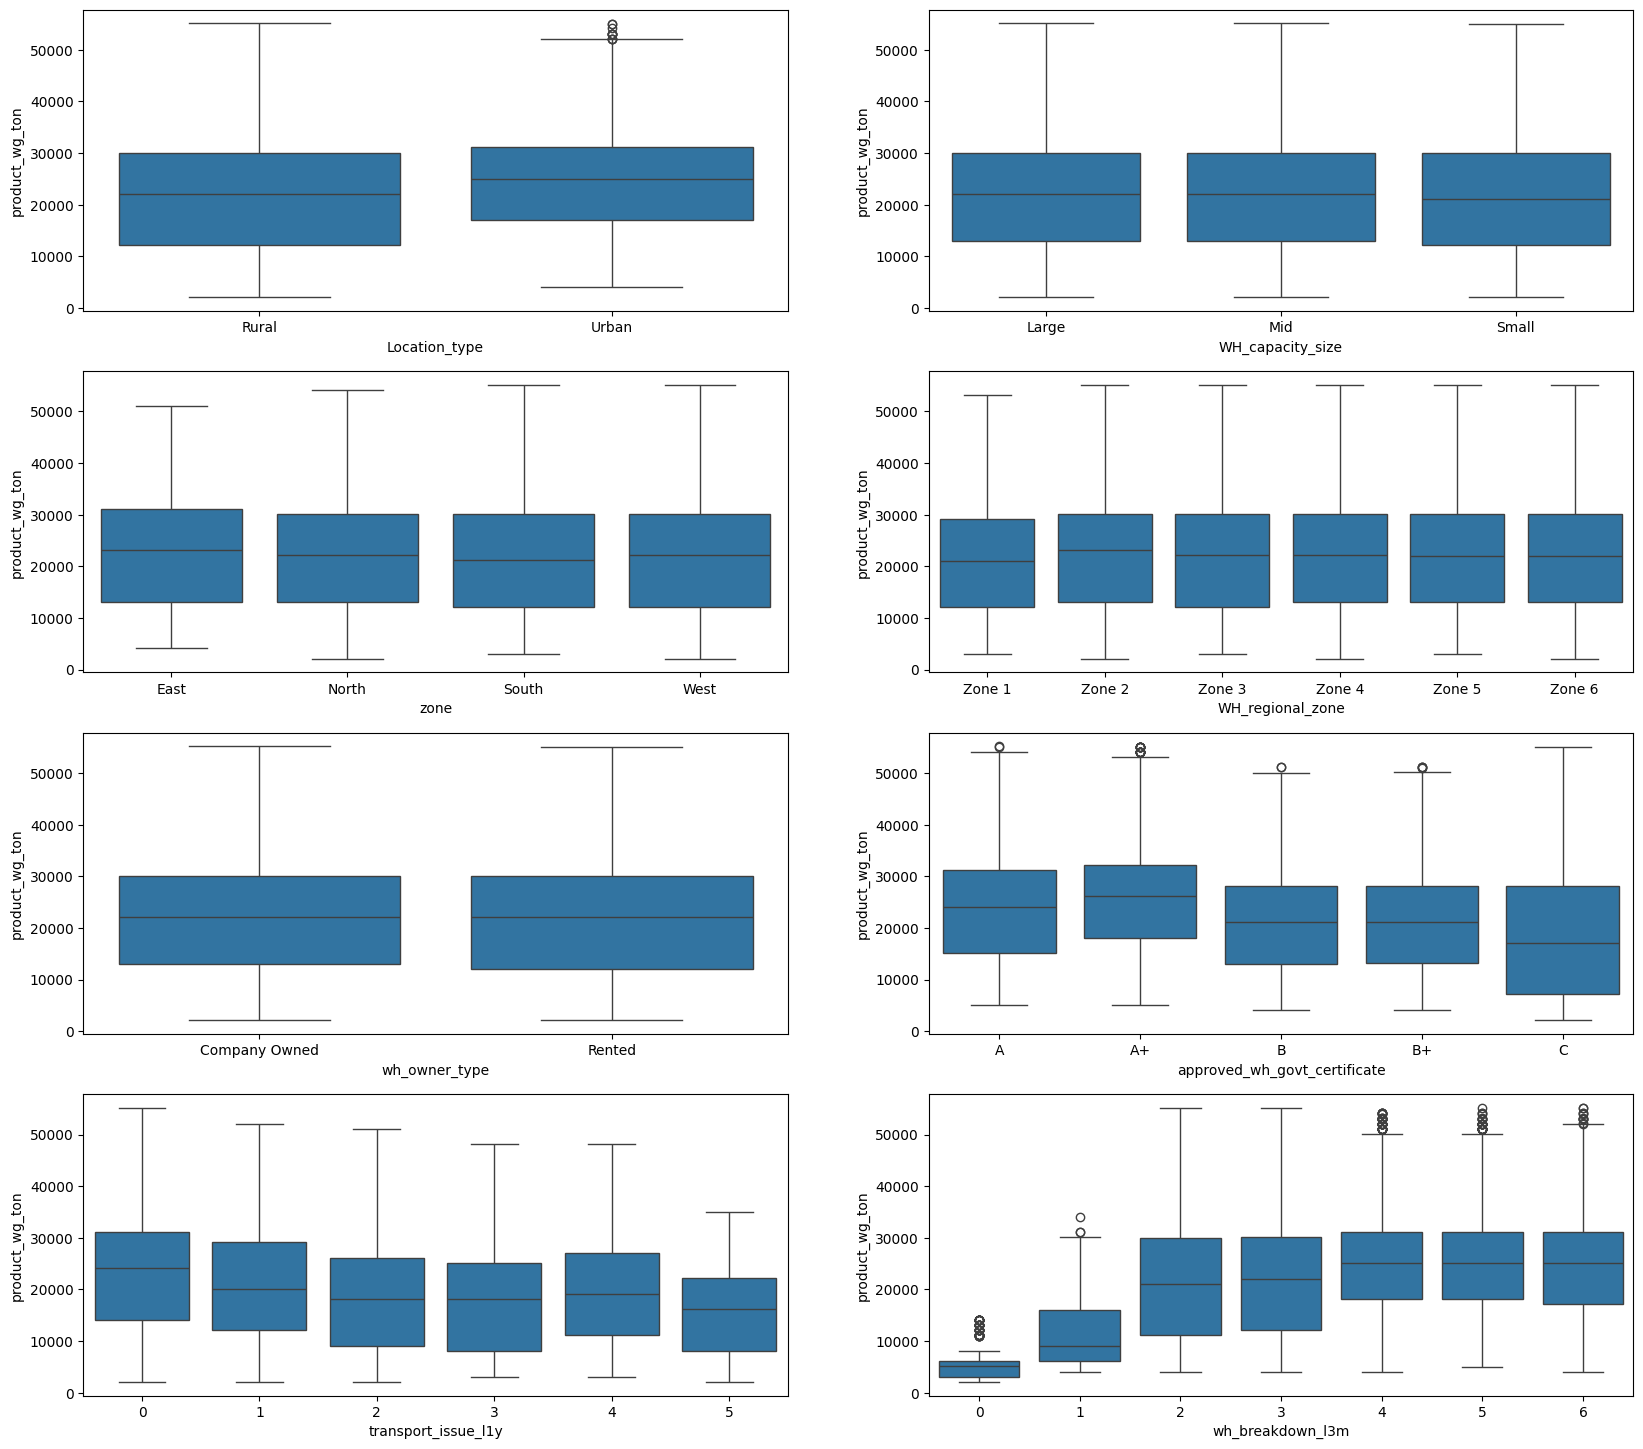

In [38]:
fig, axes = plt.subplots(nrows=4,ncols=2)
fig.set_size_inches(20,18)
sns.boxplot(x='Location_type',y='product_wg_ton',data=df,ax=axes[0][0])
sns.boxplot(x='WH_capacity_size',y='product_wg_ton',data=df,ax=axes[0][1])
sns.boxplot(x='zone',y='product_wg_ton',data=df,ax=axes[1][0])
sns.boxplot(x='WH_regional_zone',y='product_wg_ton',data=df,ax=axes[1][1])
sns.boxplot(x='wh_owner_type',y='product_wg_ton',data=df,ax=axes[2][0])
sns.boxplot(x='approved_wh_govt_certificate',y='product_wg_ton',data=df,ax=axes[2][1])
sns.boxplot(x='transport_issue_l1y',y='product_wg_ton',data=df,ax=axes[3][0])
sns.boxplot(x='wh_breakdown_l3m',y='product_wg_ton',data=df,ax=axes[3][1])
plt.show()

# Multivariate analysis

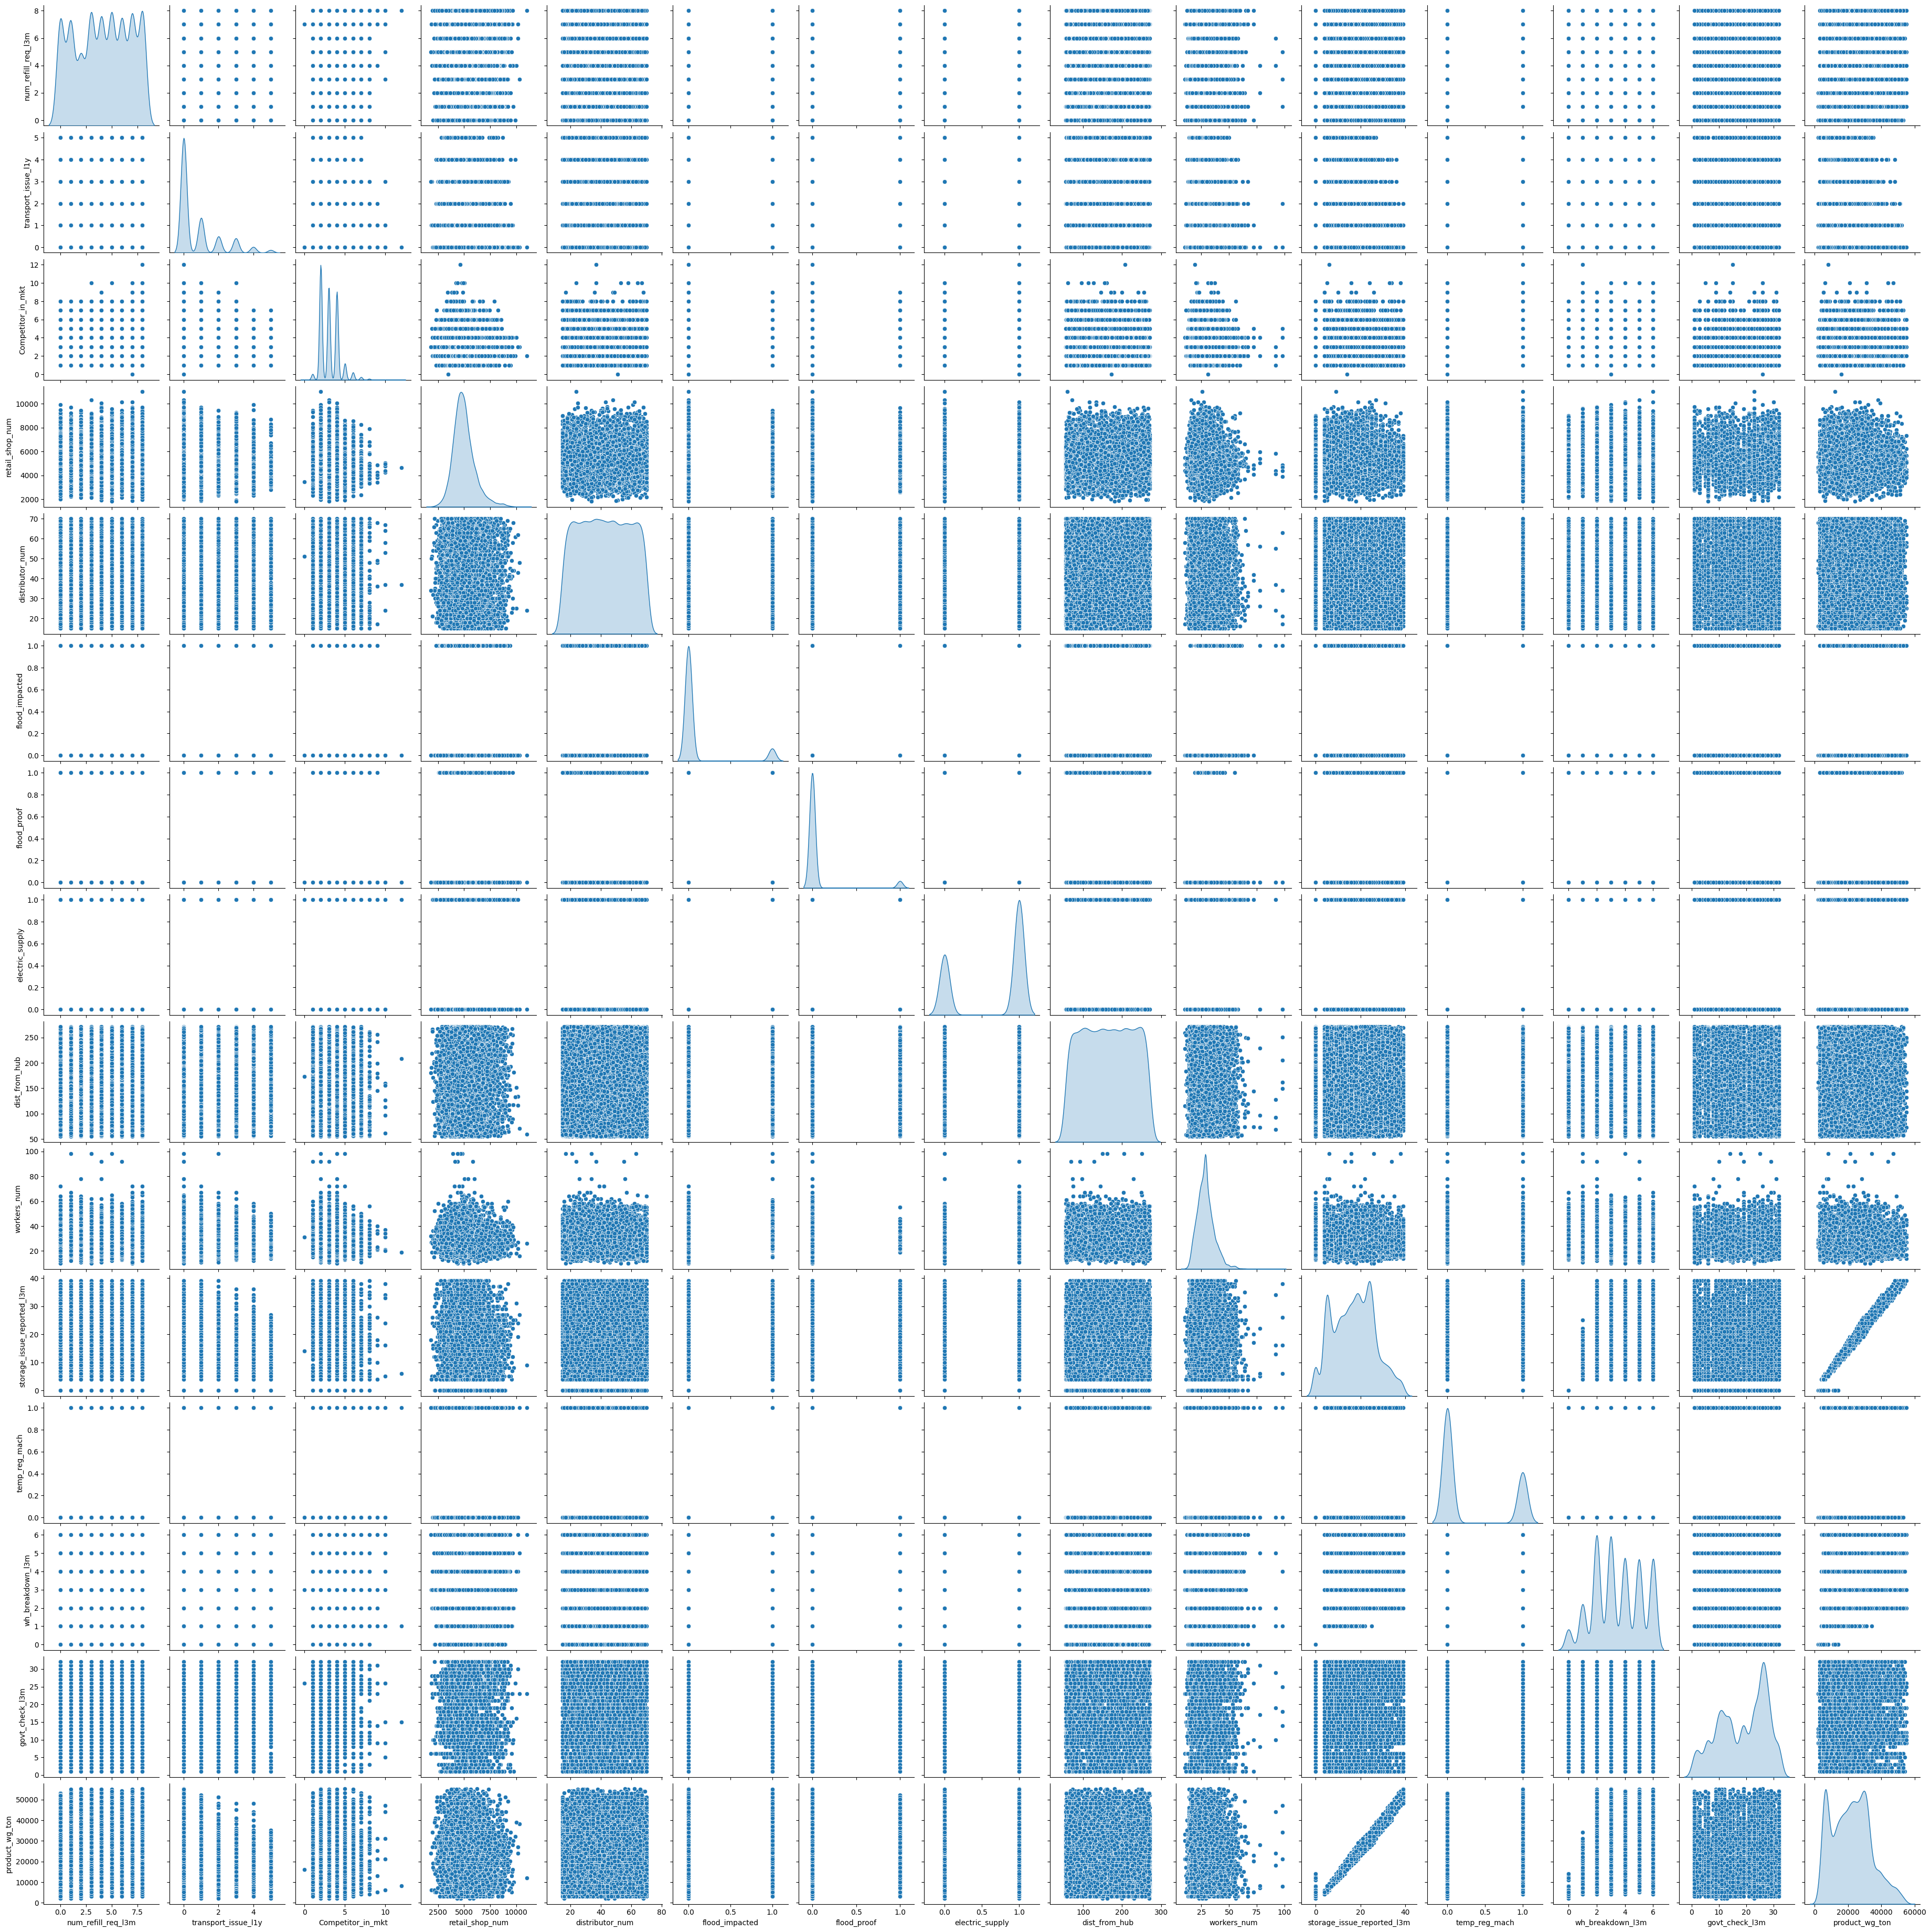

In [39]:
sns.pairplot(df,diag_kind='kde')
plt.show()

# heat map

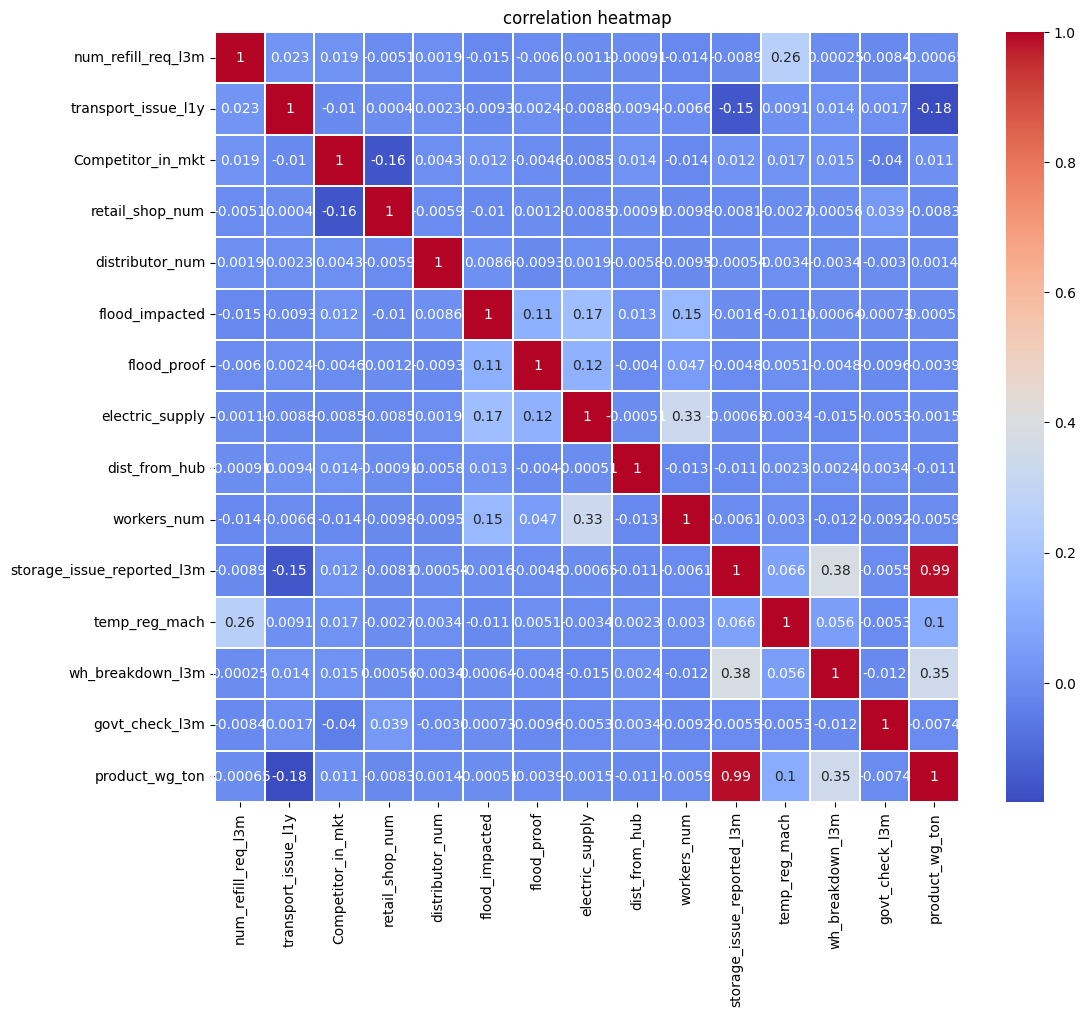

In [40]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidth=.10)
plt.title('correlation heatmap',fontsize=12)
plt.show()

# Feature Engineering

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16620 entries, 0 to 16619
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Location_type                 16620 non-null  category
 1   WH_capacity_size              16620 non-null  category
 2   zone                          16620 non-null  category
 3   WH_regional_zone              16620 non-null  category
 4   num_refill_req_l3m            16620 non-null  int64   
 5   transport_issue_l1y           16620 non-null  int64   
 6   Competitor_in_mkt             16620 non-null  int64   
 7   retail_shop_num               16620 non-null  int64   
 8   wh_owner_type                 16620 non-null  category
 9   distributor_num               16620 non-null  int64   
 10  flood_impacted                16620 non-null  int64   
 11  flood_proof                   16620 non-null  int64   
 12  electric_supply               16620 non-null  

In [42]:
df.head()

,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,Urban,Small,West,Zone 6,3,1,2,4651,Rented,24,0,1,1,91,29.0,13,0,A,5,15,17115
1,Rural,Large,North,Zone 5,0,0,4,6217,Company Owned,47,0,0,1,210,31.0,4,0,A,3,17,5074
2,Rural,Mid,South,Zone 2,1,0,4,4306,Company Owned,64,0,0,0,161,37.0,17,0,A,6,22,23137
3,Rural,Mid,North,Zone 3,7,4,2,6000,Rented,50,0,0,0,103,21.0,17,1,A+,3,27,22115
4,Rural,Large,North,Zone 5,3,1,2,4740,Company Owned,42,1,0,1,112,25.0,18,0,C,6,24,24071


In [43]:
# here 'WH_regioal_zone' converted into numerical type by slicing the zone in it
df['WH_regional_zone']=df['WH_regional_zone'].apply(lambda x:x[-1])
df.WH_regional_zone=pd.to_numeric(df.WH_regional_zone)

In [44]:
# to check
df.head()

,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,Urban,Small,West,6,3,1,2,4651,Rented,24,0,1,1,91,29.0,13,0,A,5,15,17115
1,Rural,Large,North,5,0,0,4,6217,Company Owned,47,0,0,1,210,31.0,4,0,A,3,17,5074
2,Rural,Mid,South,2,1,0,4,4306,Company Owned,64,0,0,0,161,37.0,17,0,A,6,22,23137
3,Rural,Mid,North,3,7,4,2,6000,Rented,50,0,0,0,103,21.0,17,1,A+,3,27,22115
4,Rural,Large,North,5,3,1,2,4740,Company Owned,42,1,0,1,112,25.0,18,0,C,6,24,24071


# all categorical variables are converted into numerical type using one hote

In [45]:
cat_types_features = df.select_dtypes(include = 'category')
cat_types_features.columns

Index(['Location_type', 'WH_capacity_size', 'zone', 'wh_owner_type',
       'approved_wh_govt_certificate'],
      dtype='object')

In [46]:
cat_list = ['Location_type','WH_capacity_size', 'zone', 'wh_owner_type',
       'approved_wh_govt_certificate']
cat_list

['Location_type',
 'WH_capacity_size',
 'zone',
 'wh_owner_type',
 'approved_wh_govt_certificate']

In [47]:
df1 = pd.get_dummies(df,columns = cat_list,prefix=cat_list,drop_first=True)

In [48]:
df1.head()

,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,6,3,1,2,4651,24,0,1,1,91,29.0,13,0,5,15,17115,True,False,True,False,False,True,True,False,False,False,False
1,5,0,0,4,6217,47,0,0,1,210,31.0,4,0,3,17,5074,False,False,False,True,False,False,False,False,False,False,False
2,2,1,0,4,4306,64,0,0,0,161,37.0,17,0,6,22,23137,False,True,False,False,True,False,False,False,False,False,False
3,3,7,4,2,6000,50,0,0,0,103,21.0,17,1,3,27,22115,False,True,False,True,False,False,True,True,False,False,False
4,5,3,1,2,4740,42,1,0,1,112,25.0,18,0,6,24,24071,False,False,False,True,False,False,False,False,False,False,True


In [49]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16620 entries, 0 to 16619
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   WH_regional_zone                 16620 non-null  int64  
 1   num_refill_req_l3m               16620 non-null  int64  
 2   transport_issue_l1y              16620 non-null  int64  
 3   Competitor_in_mkt                16620 non-null  int64  
 4   retail_shop_num                  16620 non-null  int64  
 5   distributor_num                  16620 non-null  int64  
 6   flood_impacted                   16620 non-null  int64  
 7   flood_proof                      16620 non-null  int64  
 8   electric_supply                  16620 non-null  int64  
 9   dist_from_hub                    16620 non-null  int64  
 10  workers_num                      16620 non-null  float64
 11  storage_issue_reported_l3m       16620 non-null  int64  
 12  temp_reg_mach     

In [50]:
# Assuming your Dataframe is named of_encoded
boolean_columns = ['Location_type_Urban','WH_capacity_size_Mid','WH_capacity_size_Small',
                   'zone_North','zone_South','zone_West','wh_owner_type_Rented','approved_wh_govt_certificate_A+',
                   'approved_wh_govt_certificate_B','approved_wh_govt_certificate_B+','approved_wh_govt_certificate_C']

# Convert boolean columns to binary (0/1) columns
df1[boolean_columns] = df1[boolean_columns].astype(int)

In [51]:
df1.head()

,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,6,3,1,2,4651,24,0,1,1,91,29.0,13,0,5,15,17115,1,0,1,0,0,1,1,0,0,0,0
1,5,0,0,4,6217,47,0,0,1,210,31.0,4,0,3,17,5074,0,0,0,1,0,0,0,0,0,0,0
2,2,1,0,4,4306,64,0,0,0,161,37.0,17,0,6,22,23137,0,1,0,0,1,0,0,0,0,0,0
3,3,7,4,2,6000,50,0,0,0,103,21.0,17,1,3,27,22115,0,1,0,1,0,0,1,1,0,0,0
4,5,3,1,2,4740,42,1,0,1,112,25.0,18,0,6,24,24071,0,0,0,1,0,0,0,0,0,0,1


In [52]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16620 entries, 0 to 16619
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   WH_regional_zone                 16620 non-null  int64  
 1   num_refill_req_l3m               16620 non-null  int64  
 2   transport_issue_l1y              16620 non-null  int64  
 3   Competitor_in_mkt                16620 non-null  int64  
 4   retail_shop_num                  16620 non-null  int64  
 5   distributor_num                  16620 non-null  int64  
 6   flood_impacted                   16620 non-null  int64  
 7   flood_proof                      16620 non-null  int64  
 8   electric_supply                  16620 non-null  int64  
 9   dist_from_hub                    16620 non-null  int64  
 10  workers_num                      16620 non-null  float64
 11  storage_issue_reported_l3m       16620 non-null  int64  
 12  temp_reg_mach     

# correlation after one hot encoding

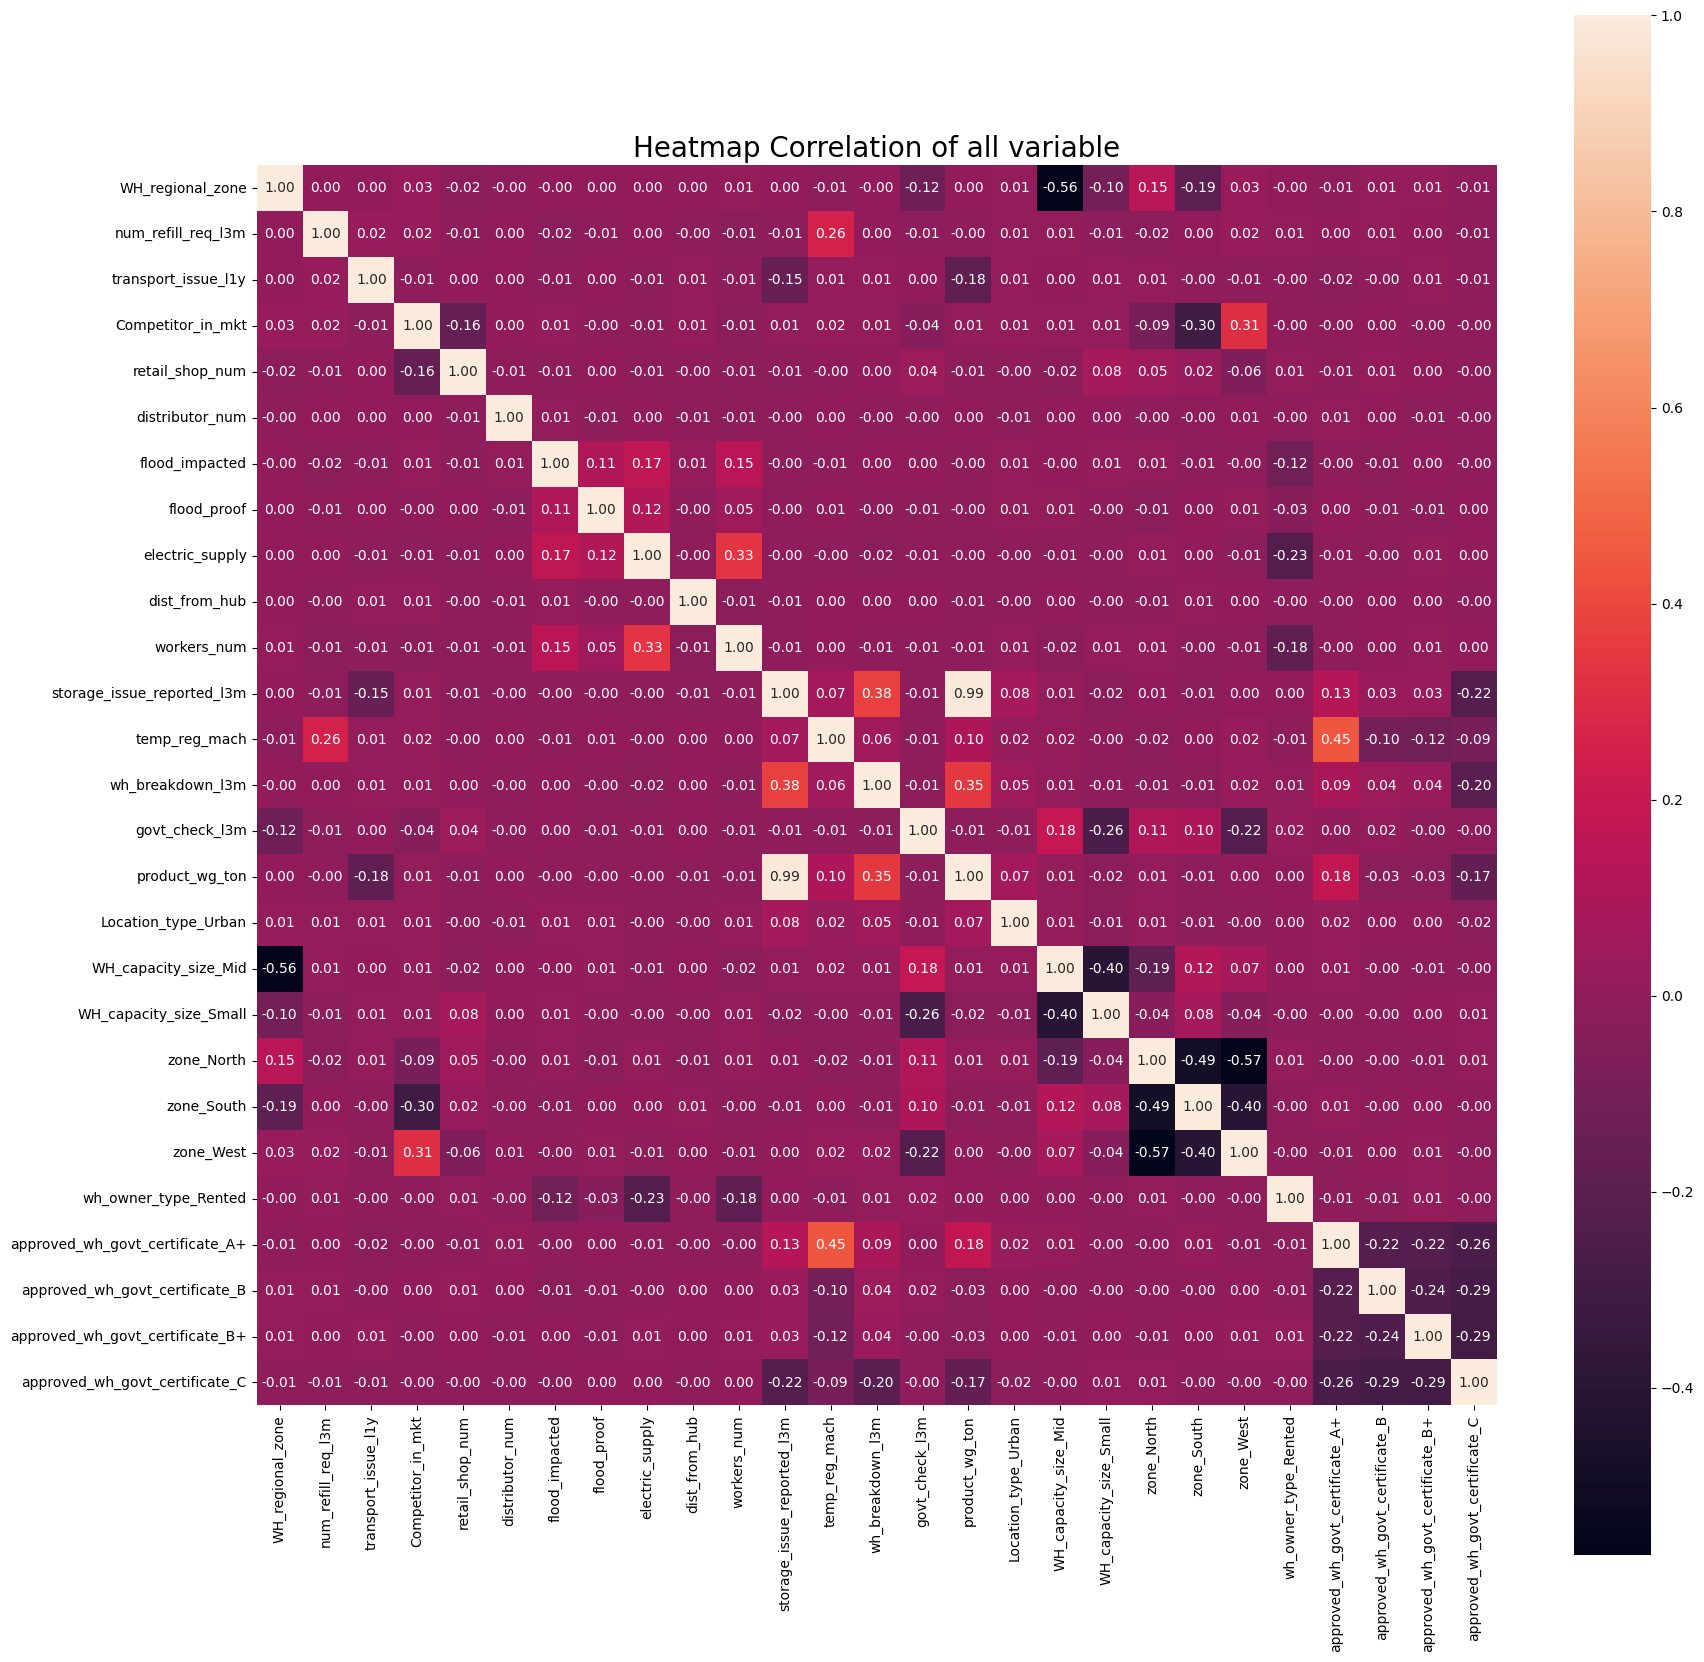

In [53]:
plt.figure(figsize=(20,20))
ax = sns.heatmap(df1.corr(),cbar=True, annot=True, square=True, fmt='.2f',annot_kws={'size':10})
plt.title('Heatmap Correlation of all variable',fontsize=20, fontweight=100)#title with fontsize 20
plt.show()

# checking outliers

In [54]:
df1.describe()

,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
count,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000,16620.000000
mean,4.254392,4.126655,0.780927,3.103129,4983.904994,42.473706,0.096871,0.056017,0.655716,163.521901,28.911490,17.127196,0.306137,3.491095,18.727377,22098.420096,0.081107,0.402587,0.191697,0.409146,0.254091,0.320096,0.459988,0.166727,0.193742,0.196149,0.254934
std,1.666568,2.606241,1.206351,1.147711,1051.032239,16.090000,0.295791,0.229961,0.475149,62.701193,7.683065,9.163901,0.460901,1.688614,8.619857,11620.337346,0.273008,0.490434,0.393648,0.491691,0.435362,0.466527,0.498411,0.372743,0.395241,0.397095,0.435837
min,1.000000,0.000000,0.000000,0.000000,1821.000000,15.000000,0.000000,0.000000,0.000000,55.000000,10.000000,0.000000,0.000000,0.000000,1.000000,2093.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,0.000000,2.000000,4309.000000,29.000000,0.000000,0.000000,0.000000,109.000000,24.000000,10.000000,0.000000,2.000000,11.000000,13057.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,4.000000,0.000000,3.000000,4856.000000,42.000000,0.000000,0.000000,1.000000,164.000000,28.000000,18.000000,0.000000,3.000000,19.000000,22099.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,6.000000,1.000000,4.000000,5500.000000,56.000000,0.000000,0.000000,1.000000,218.000000,33.000000,24.000000,1.000000,5.000000,26.000000,30103.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,6.000000,8.000000,5.000000,12.000000,11008.000000,70.000000,1.000000,1.000000,1.000000,271.000000,98.000000,39.000000,1.000000,6.000000,32.000000,55151.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


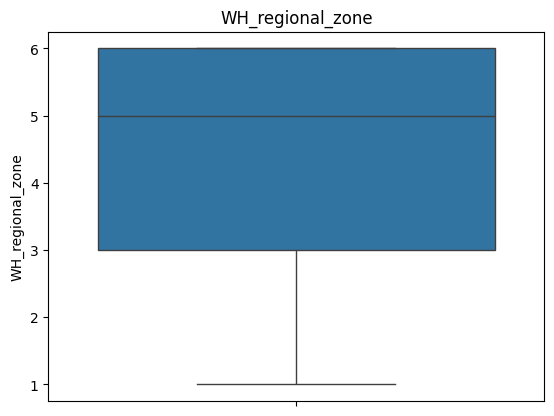

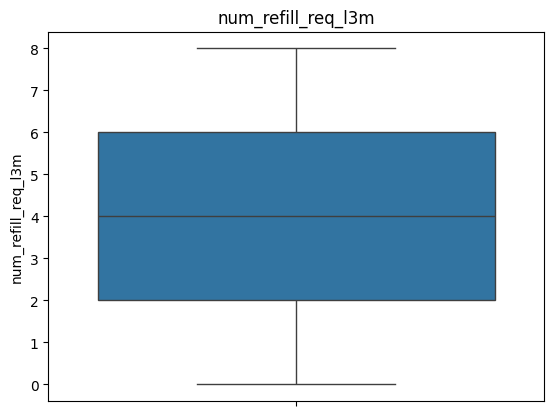

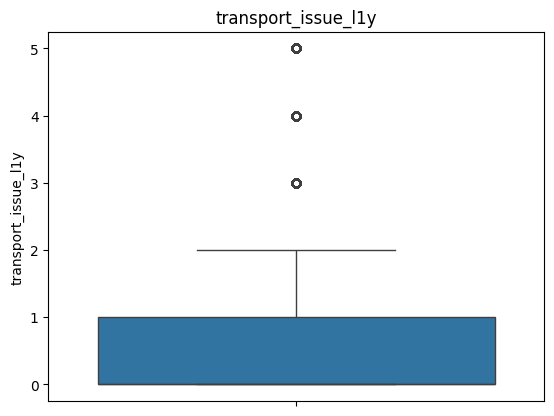

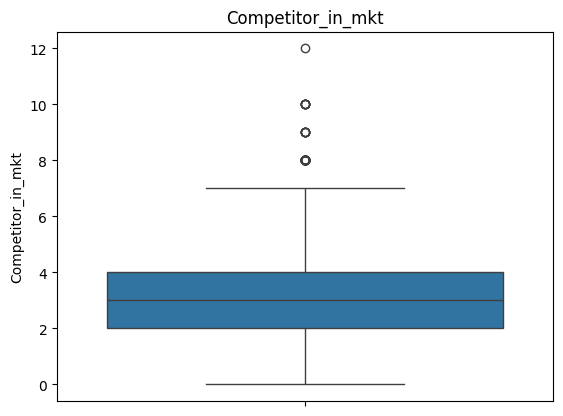

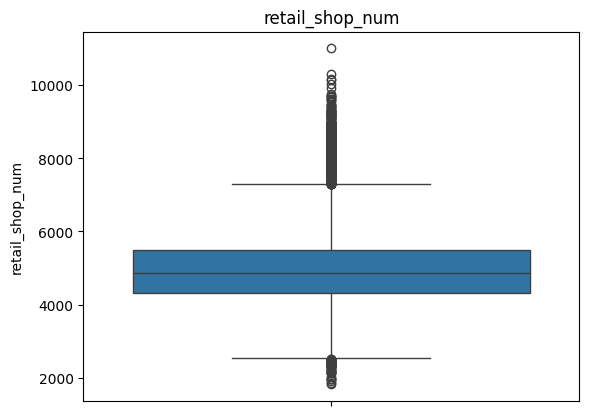

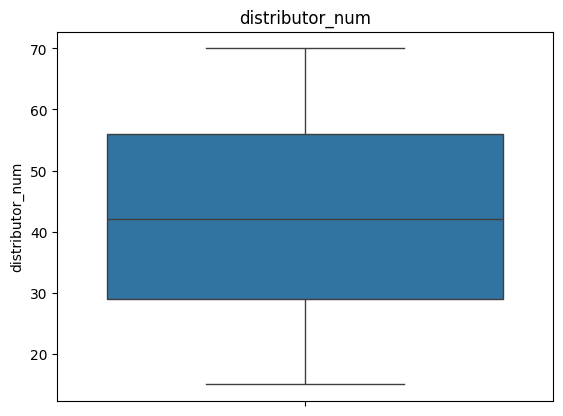

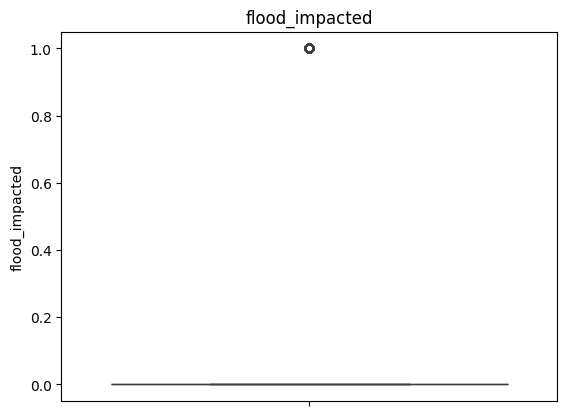

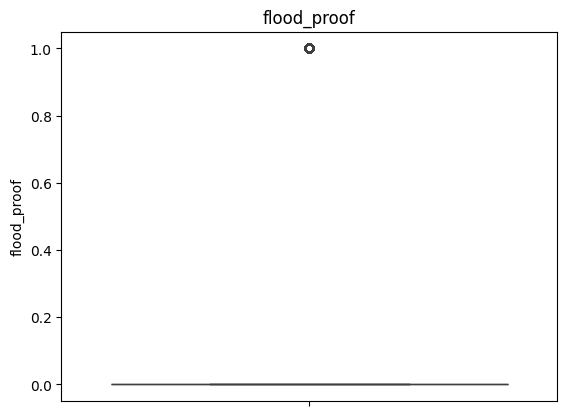

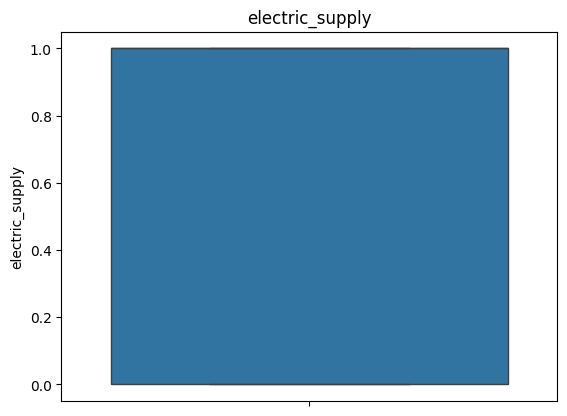

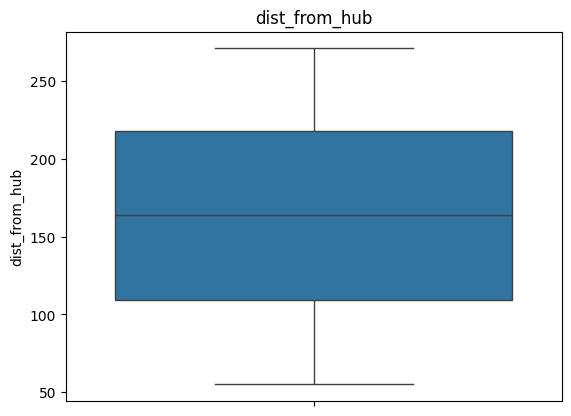

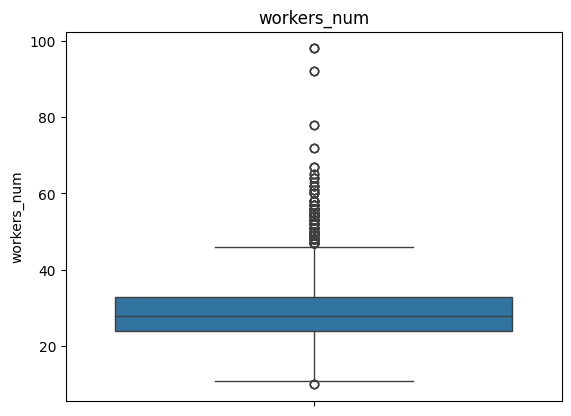

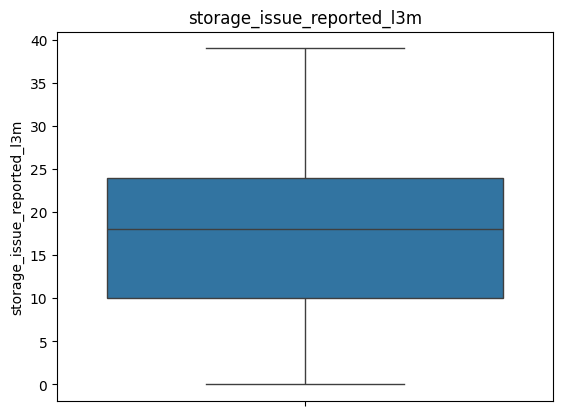

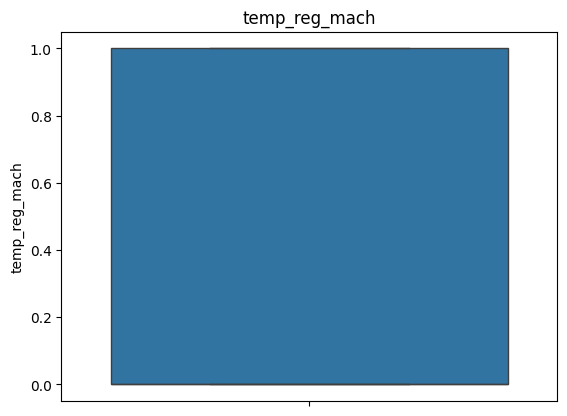

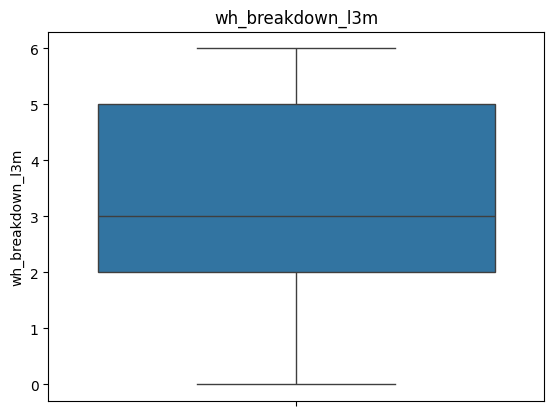

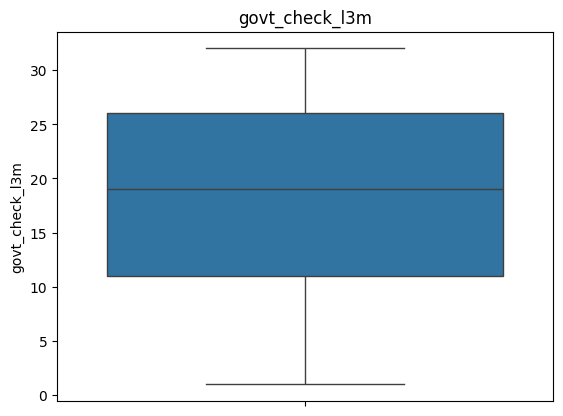

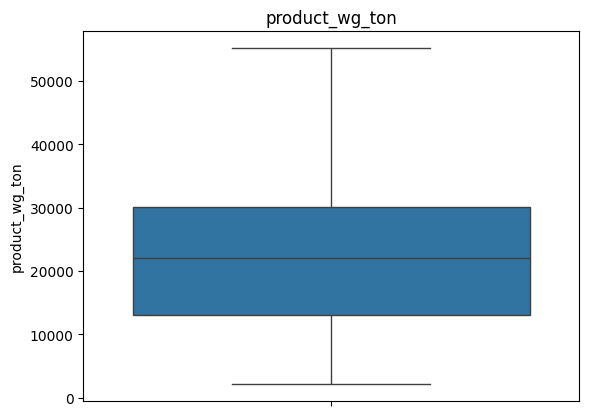

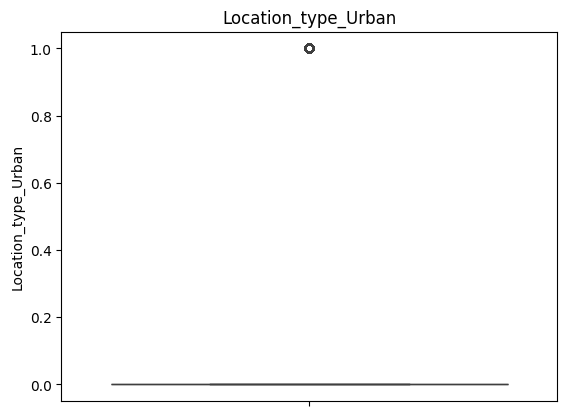

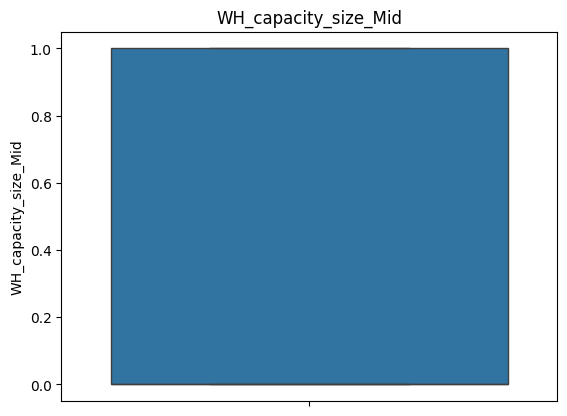

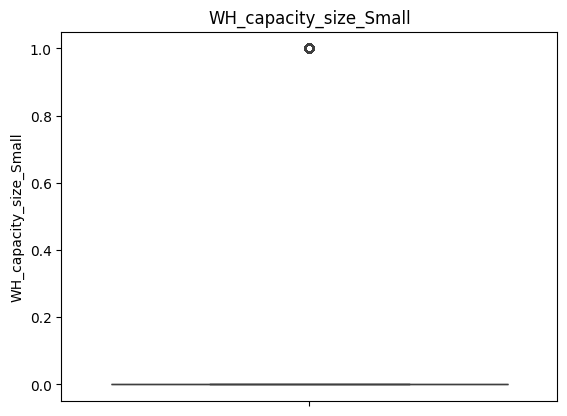

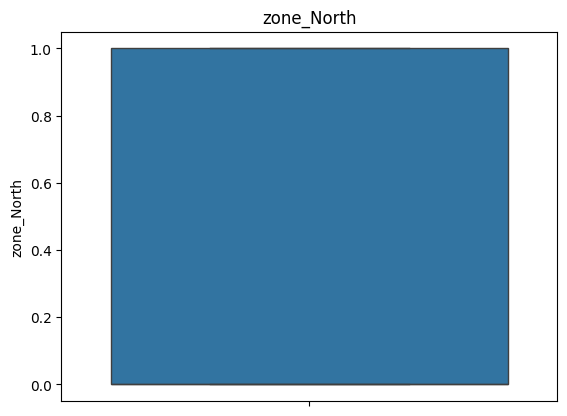

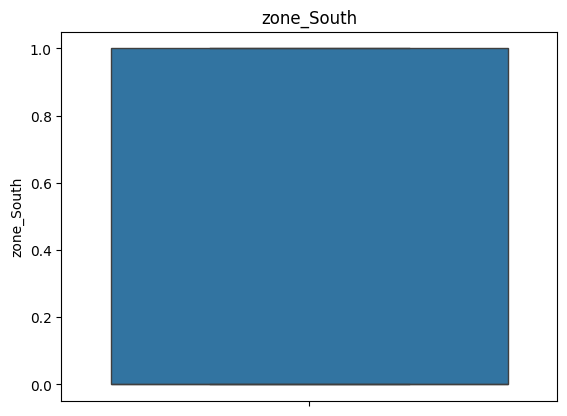

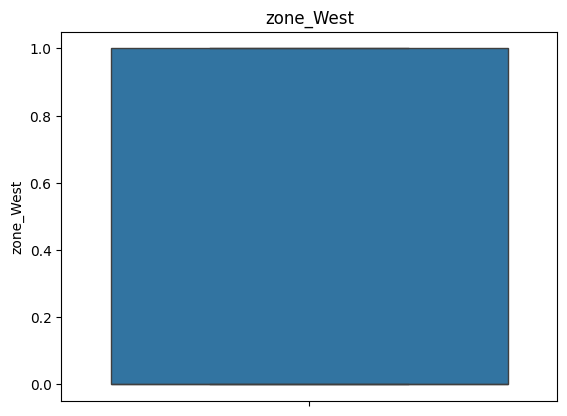

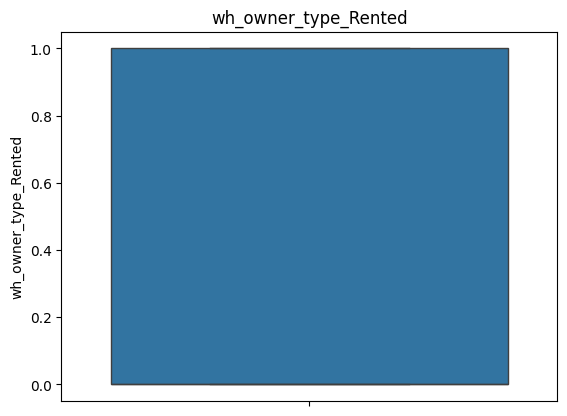

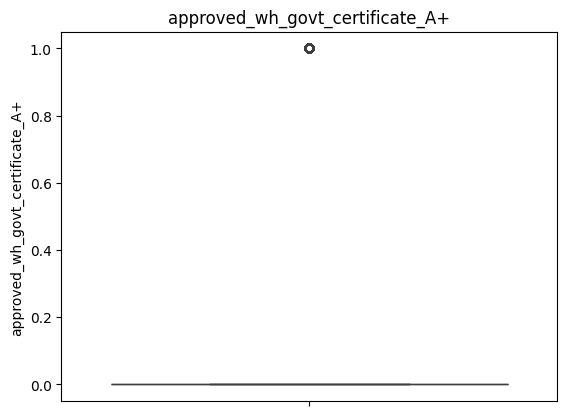

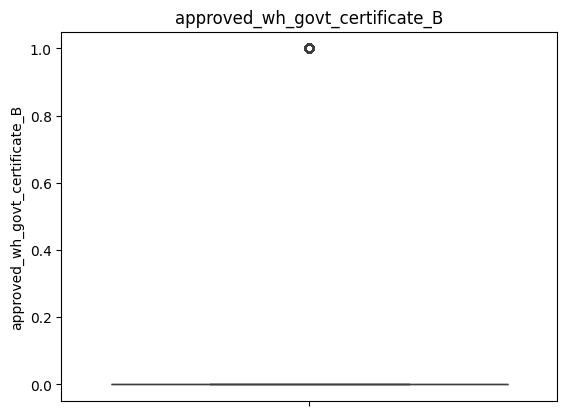

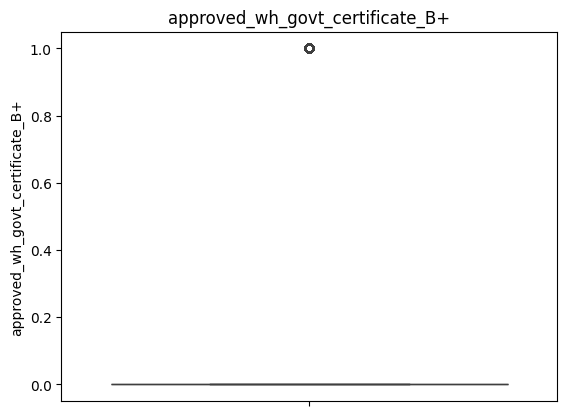

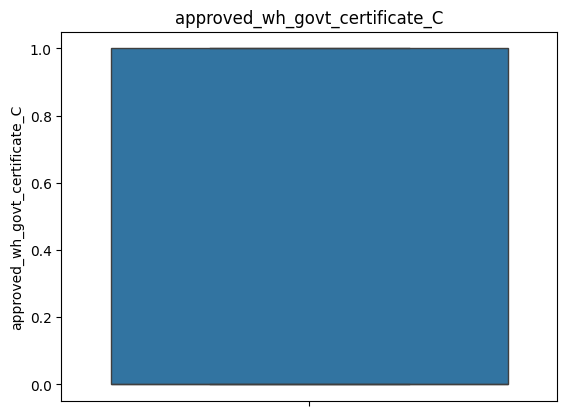

In [55]:
for i in df1.columns:
    sns.boxplot(df1[i])
    plt.title(i)
    plt.show()

# splitting of dependent variables and independent variable

In [56]:
x = df1.drop(['product_wg_ton'],axis=1)

In [57]:
y = df1['product_wg_ton']

# splitting data into train and test

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=101)

# standardaization

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [61]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [62]:
y_train

5244     52093
1984     13067
6728     32149
4400     30083
12415    37089
         ...  
2623     49101
12363    26064
5695     31151
8006     46126
13151    24133
Name: product_wg_ton, Length: 11634, dtype: int64

# MODEL BUILDING

In [63]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [64]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt( mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [65]:
models = {'Linear Regression':LinearRegression(),
         'K-Neighbors Regressor':KNeighborsRegressor(),
         'Decision Tree':DecisionTreeRegressor(),
         'Random Forest Regressor':RandomForestRegressor(),
         'Support vector machine (SVM)':SVR(kernel='linear')}
model_list = []
r2_list = []

for model_name, model in models.items():
    model.fit(x_train, y_train) # Train model

    #make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    #Evaluate train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(model_name)
    model_list.append(model_name)

    print('Model performance for Training set')
    print('- Root Mean Squared Error:{:.4f}'.format(model_train_rmse))
    print('- Mean Absolute Error:{:.4f}'.format(model_train_mae))
    print('- R2 Score: {:.4f}'.format(model_train_r2))

    print('-----------------------------------------')
    
    print('Model performance for Test set')
    print('- Root Mean Squared Error:{:.4f}'.format(model_test_rmse))
    print('- Mean Absolute Error:{:.4f}'.format(model_test_mae))
    print('- R2 Score: {:.4f}'.format(model_test_r2))

    r2_list.append(model_test_r2)
    


Linear Regression
Model performance for Training set
- Root Mean Squared Error:1377.3098
- Mean Absolute Error:1009.5091
- R2 Score: 0.9859
-----------------------------------------
Model performance for Test set
- Root Mean Squared Error:1438.0110
- Mean Absolute Error:1023.9987
- R2 Score: 0.9848
K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error:5501.2946
- Mean Absolute Error:4359.7688
- R2 Score: 0.7750
-----------------------------------------
Model performance for Test set
- Root Mean Squared Error:6691.9913
- Mean Absolute Error:5311.9108
- R2 Score: 0.6710
Decision Tree
Model performance for Training set
- Root Mean Squared Error:0.0000
- Mean Absolute Error:0.0000
- R2 Score: 1.0000
-----------------------------------------
Model performance for Test set
- Root Mean Squared Error:1329.4792
- Mean Absolute Error:881.1340
- R2 Score: 0.9870
Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error:365.4385
- Mean Absolu

# overall results

In [66]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
3,Random Forest Regressor,0.992858
2,Decision Tree,0.987015
0,Linear Regression,0.984809
4,Support vector machine (SVM),0.914851
1,K-Neighbors Regressor,0.671011


# final model

In [67]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
random_forest = RandomForestRegressor(random_state=42) # you can add hyperparameters if needed 
random_forest.fit(x_train,y_train)

#make predictions
y_train_pred_rf = random_forest.predict(x_train)
y_test_pred_rf = random_forest.predict(x_test)

#Evaluate train and test dataset
model_train_mae_rf, model_train_rmse_rf, model_train_r2_rf = evaluate_model(y_train, y_train_pred_rf)
model_test_mae_rf, model_test_rmse_rf, model_test_r2_rf = evaluate_model(y_test, y_test_pred_rf)

# print result
print('Random Forest Regressor Model for Training set')
print('- Root Mean Squared Error:{:.4f}'.format(model_train_rmse_rf))
print('- Mean Absolute Error:{:.4f}'.format(model_train_mae_rf))
print('- R2 Score: {:.4f}'.format(model_train_r2_rf))

print('-----------------------------------------')
    
print('Random Forest Regressor Model Performance for Test set')
print('- Root Mean Squared Error:{:.4f}'.format(model_test_rmse_rf))
print('- Mean Absolute Error:{:.4f}'.format(model_test_mae_rf))
print('- R2 Score: {:.4f}'.format(model_test_r2_rf))

Random Forest Regressor Model for Training set
- Root Mean Squared Error:362.0133
- Mean Absolute Error:268.6990
- R2 Score: 0.9990
-----------------------------------------
Random Forest Regressor Model Performance for Test set
- Root Mean Squared Error:979.7426
- Mean Absolute Error:722.2469
- R2 Score: 0.9929


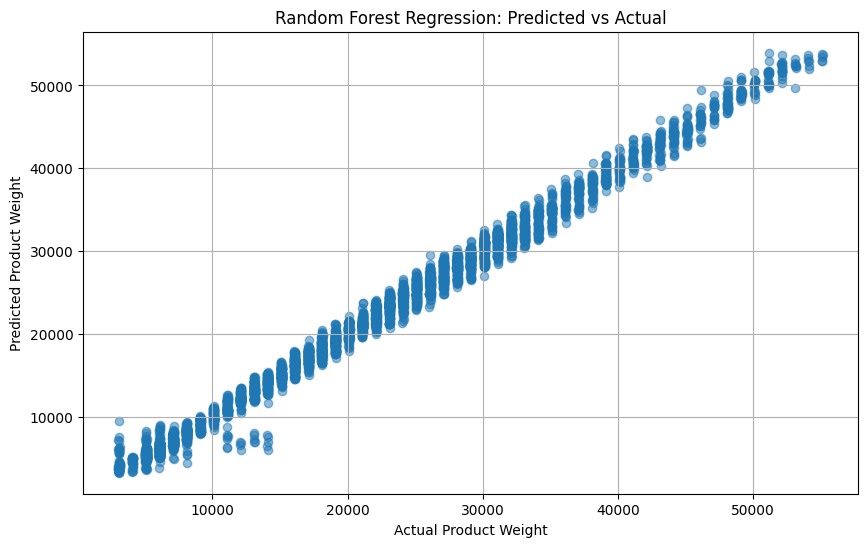

In [68]:
# plot predicted vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test,y_test_pred_rf, alpha=0.5)
plt.xlabel('Actual Product Weight')
plt.ylabel('Predicted Product Weight')
plt.title('Random Forest Regression: Predicted vs Actual')
plt.grid(True)
plt.show()

# conclusion

In [69]:
# test data

In [70]:
te = pd.read_csv('supply_test.csv')

In [71]:
te

,Unnamed: 0,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,16621,WH_116621,EID_66621,Rural,Large,North,Zone 5,5,0,3,5590,Company Owned,15,0,0,0,156,30.0,2006.0,24,0,A,2,5,30132
1,16622,WH_116622,EID_66622,Rural,Large,North,Zone 5,5,0,2,5856,Company Owned,40,0,0,1,79,31.0,2019.0,5,1,C,2,24,6075
2,16623,WH_116623,EID_66623,Rural,Small,North,Zone 6,3,0,3,4803,Rented,40,0,0,1,70,41.0,2008.0,19,1,A+,5,9,24076
3,16624,WH_116624,EID_66624,Rural,Mid,West,Zone 4,5,2,2,4784,Rented,15,0,0,1,255,33.0,2017.0,9,1,A+,3,11,13092
4,16625,WH_116625,EID_66625,Urban,Mid,North,Zone 4,6,0,4,3699,Rented,24,0,0,0,205,20.0,1999.0,25,0,B,4,26,29071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524,22145,WH_122145,EID_72145,Rural,Large,North,Zone 6,8,1,3,5030,Rented,46,0,0,1,203,28.0,2007.0,22,1,A+,2,4,29138
5525,22146,WH_122146,EID_72146,Rural,Small,South,Zone 6,3,1,3,4320,Rented,60,0,0,0,170,NaN,NaN,26,0,C,5,9,33108
5526,22147,WH_122147,EID_72147,Rural,Large,North,Zone 6,7,2,2,5268,Company Owned,64,0,0,0,99,22.0,NaN,20,0,B+,6,4,24072
5527,22148,WH_122148,EID_72148,Rural,Large,North,Zone 6,6,2,4,4378,Rented,32,0,0,0,220,17.0,NaN,13,0,B,3,28,15055


In [72]:
te.drop('Unnamed: 0',axis=1, inplace=True)

In [73]:
pd.options.display.max_columns = None
te.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_116621,EID_66621,Rural,Large,North,Zone 5,5,0,3,5590,Company Owned,15,0,0,0,156,30.0,2006.0,24,0,A,2,5,30132
1,WH_116622,EID_66622,Rural,Large,North,Zone 5,5,0,2,5856,Company Owned,40,0,0,1,79,31.0,2019.0,5,1,C,2,24,6075
2,WH_116623,EID_66623,Rural,Small,North,Zone 6,3,0,3,4803,Rented,40,0,0,1,70,41.0,2008.0,19,1,A+,5,9,24076
3,WH_116624,EID_66624,Rural,Mid,West,Zone 4,5,2,2,4784,Rented,15,0,0,1,255,33.0,2017.0,9,1,A+,3,11,13092
4,WH_116625,EID_66625,Urban,Mid,North,Zone 4,6,0,4,3699,Rented,24,0,0,0,205,20.0,1999.0,25,0,B,4,26,29071


In [74]:
te.shape

(5529, 24)

In [75]:
te.columns

Index(['Ware_house_ID', 'WH_Manager_ID', 'Location_type', 'WH_capacity_size',
       'zone', 'WH_regional_zone', 'num_refill_req_l3m', 'transport_issue_l1y',
       'Competitor_in_mkt', 'retail_shop_num', 'wh_owner_type',
       'distributor_num', 'flood_impacted', 'flood_proof', 'electric_supply',
       'dist_from_hub', 'workers_num', 'wh_est_year',
       'storage_issue_reported_l3m', 'temp_reg_mach',
       'approved_wh_govt_certificate', 'wh_breakdown_l3m', 'govt_check_l3m',
       'product_wg_ton'],
      dtype='object')

# Descriptive Details

In [76]:
te.describe()

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
count,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5319.000000,2844.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
mean,4.007235,0.765600,3.106167,4980.695424,42.128052,0.104178,0.049919,0.657262,163.899982,29.010528,2009.572785,17.085549,0.298426,3.477302,18.892205,22052.334599
std,2.604325,1.187567,1.128396,1049.617325,15.959934,0.305519,0.217797,0.474668,62.544704,7.848478,7.473201,9.206551,0.457609,1.700717,8.716737,11645.738485
min,0.000000,0.000000,1.000000,1953.000000,15.000000,0.000000,0.000000,0.000000,55.000000,10.000000,1996.000000,0.000000,0.000000,0.000000,1.000000,2065.000000
25%,2.000000,0.000000,2.000000,4310.000000,28.000000,0.000000,0.000000,0.000000,110.000000,24.000000,2003.000000,10.000000,0.000000,2.000000,11.000000,12143.000000
50%,4.000000,0.000000,3.000000,4863.000000,42.000000,0.000000,0.000000,1.000000,165.000000,28.000000,2010.000000,17.000000,0.000000,3.000000,21.000000,22099.000000
75%,6.000000,1.000000,4.000000,5492.000000,56.000000,0.000000,0.000000,1.000000,218.000000,33.000000,2016.000000,24.000000,1.000000,5.000000,26.000000,30099.000000
max,8.000000,5.000000,9.000000,10846.000000,70.000000,1.000000,1.000000,1.000000,271.000000,98.000000,2023.000000,39.000000,1.000000,6.000000,32.000000,55144.000000


In [77]:
# Understanding of attributes

In [78]:
te.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 5529 non-null   object 
 1   WH_Manager_ID                 5529 non-null   object 
 2   Location_type                 5529 non-null   object 
 3   WH_capacity_size              5529 non-null   object 
 4   zone                          5529 non-null   object 
 5   WH_regional_zone              5529 non-null   object 
 6   num_refill_req_l3m            5529 non-null   int64  
 7   transport_issue_l1y           5529 non-null   int64  
 8   Competitor_in_mkt             5529 non-null   int64  
 9   retail_shop_num               5529 non-null   int64  
 10  wh_owner_type                 5529 non-null   object 
 11  distributor_num               5529 non-null   int64  
 12  flood_impacted                5529 non-null   int64  
 13  flo

In [79]:
# EDA

In [80]:
te.WH_Manager_ID.nunique()

5529

In [81]:
te.drop(['WH_Manager_ID','Ware_house_ID'], axis=1,inplace=True)

In [82]:
te.head()

,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,Rural,Large,North,Zone 5,5,0,3,5590,Company Owned,15,0,0,0,156,30.0,2006.0,24,0,A,2,5,30132
1,Rural,Large,North,Zone 5,5,0,2,5856,Company Owned,40,0,0,1,79,31.0,2019.0,5,1,C,2,24,6075
2,Rural,Small,North,Zone 6,3,0,3,4803,Rented,40,0,0,1,70,41.0,2008.0,19,1,A+,5,9,24076
3,Rural,Mid,West,Zone 4,5,2,2,4784,Rented,15,0,0,1,255,33.0,2017.0,9,1,A+,3,11,13092
4,Urban,Mid,North,Zone 4,6,0,4,3699,Rented,24,0,0,0,205,20.0,1999.0,25,0,B,4,26,29071


In [83]:
# missing values

In [84]:
len(te)

5529

In [85]:
te.isnull().sum()*100/len(te)

Location_type                    0.000000
WH_capacity_size                 0.000000
zone                             0.000000
WH_regional_zone                 0.000000
num_refill_req_l3m               0.000000
transport_issue_l1y              0.000000
Competitor_in_mkt                0.000000
retail_shop_num                  0.000000
wh_owner_type                    0.000000
distributor_num                  0.000000
flood_impacted                   0.000000
flood_proof                      0.000000
electric_supply                  0.000000
dist_from_hub                    0.000000
workers_num                      3.798155
wh_est_year                     48.562127
storage_issue_reported_l3m       0.000000
temp_reg_mach                    0.000000
approved_wh_govt_certificate     3.725809
wh_breakdown_l3m                 0.000000
govt_check_l3m                   0.000000
product_wg_ton                   0.000000
dtype: float64

In [86]:
te['approved_wh_govt_certificate'].mode()

0    C
Name: approved_wh_govt_certificate, dtype: object

In [87]:
# we can drop the warehous estimated feature as there is 48% missing data and there is no need to predict dependent variales
te.drop(['wh_est_year'], axis=1, inplace=True)

In [88]:
te.approved_wh_govt_certificate.fillna(te.approved_wh_govt_certificate.mode()[0],inplace = True)

In [89]:
te.workers_num.fillna(te.workers_num.mean(),inplace = True)

In [90]:
te.isnull().sum()*100/len(te)

Location_type                   0.0
WH_capacity_size                0.0
zone                            0.0
WH_regional_zone                0.0
num_refill_req_l3m              0.0
transport_issue_l1y             0.0
Competitor_in_mkt               0.0
retail_shop_num                 0.0
wh_owner_type                   0.0
distributor_num                 0.0
flood_impacted                  0.0
flood_proof                     0.0
electric_supply                 0.0
dist_from_hub                   0.0
workers_num                     0.0
storage_issue_reported_l3m      0.0
temp_reg_mach                   0.0
approved_wh_govt_certificate    0.0
wh_breakdown_l3m                0.0
govt_check_l3m                  0.0
product_wg_ton                  0.0
dtype: float64

In [91]:
# duplicate value

In [92]:
te.duplicated().sum()

np.int64(0)

In [93]:
# converting datatype

In [94]:
before = te.dtypes
before

Location_type                    object
WH_capacity_size                 object
zone                             object
WH_regional_zone                 object
num_refill_req_l3m                int64
transport_issue_l1y               int64
Competitor_in_mkt                 int64
retail_shop_num                   int64
wh_owner_type                    object
distributor_num                   int64
flood_impacted                    int64
flood_proof                       int64
electric_supply                   int64
dist_from_hub                     int64
workers_num                     float64
storage_issue_reported_l3m        int64
temp_reg_mach                     int64
approved_wh_govt_certificate     object
wh_breakdown_l3m                  int64
govt_check_l3m                    int64
product_wg_ton                    int64
dtype: object

In [95]:

te['Location_type'] = te['Location_type'].astype('category')
te['WH_capacity_size'] = te['WH_capacity_size'].astype('category')
te['zone'] = te['zone'].astype('category')
te['WH_regional_zone'] = te['WH_regional_zone'].astype('category')
te['wh_owner_type'] = te['wh_owner_type'].astype('category')
te['approved_wh_govt_certificate'] = te['approved_wh_govt_certificate'].astype('category')

In [96]:
after = te.dtypes
after

Location_type                   category
WH_capacity_size                category
zone                            category
WH_regional_zone                category
num_refill_req_l3m                 int64
transport_issue_l1y                int64
Competitor_in_mkt                  int64
retail_shop_num                    int64
wh_owner_type                   category
distributor_num                    int64
flood_impacted                     int64
flood_proof                        int64
electric_supply                    int64
dist_from_hub                      int64
workers_num                      float64
storage_issue_reported_l3m         int64
temp_reg_mach                      int64
approved_wh_govt_certificate    category
wh_breakdown_l3m                   int64
govt_check_l3m                     int64
product_wg_ton                     int64
dtype: object

In [97]:
# Feature Engineering

In [98]:
te.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Location_type                 5529 non-null   category
 1   WH_capacity_size              5529 non-null   category
 2   zone                          5529 non-null   category
 3   WH_regional_zone              5529 non-null   category
 4   num_refill_req_l3m            5529 non-null   int64   
 5   transport_issue_l1y           5529 non-null   int64   
 6   Competitor_in_mkt             5529 non-null   int64   
 7   retail_shop_num               5529 non-null   int64   
 8   wh_owner_type                 5529 non-null   category
 9   distributor_num               5529 non-null   int64   
 10  flood_impacted                5529 non-null   int64   
 11  flood_proof                   5529 non-null   int64   
 12  electric_supply               5529 non-null   in

In [99]:
te.head()

,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,Rural,Large,North,Zone 5,5,0,3,5590,Company Owned,15,0,0,0,156,30.0,24,0,A,2,5,30132
1,Rural,Large,North,Zone 5,5,0,2,5856,Company Owned,40,0,0,1,79,31.0,5,1,C,2,24,6075
2,Rural,Small,North,Zone 6,3,0,3,4803,Rented,40,0,0,1,70,41.0,19,1,A+,5,9,24076
3,Rural,Mid,West,Zone 4,5,2,2,4784,Rented,15,0,0,1,255,33.0,9,1,A+,3,11,13092
4,Urban,Mid,North,Zone 4,6,0,4,3699,Rented,24,0,0,0,205,20.0,25,0,B,4,26,29071


In [100]:
# here 'WH_regioal_zone' converted into numerical type by slicing the zone in it
te['WH_regional_zone']=te['WH_regional_zone'].apply(lambda x:x[-1])
te.WH_regional_zone=pd.to_numeric(te.WH_regional_zone)

In [101]:
# to check
te.head()

,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,Rural,Large,North,5,5,0,3,5590,Company Owned,15,0,0,0,156,30.0,24,0,A,2,5,30132
1,Rural,Large,North,5,5,0,2,5856,Company Owned,40,0,0,1,79,31.0,5,1,C,2,24,6075
2,Rural,Small,North,6,3,0,3,4803,Rented,40,0,0,1,70,41.0,19,1,A+,5,9,24076
3,Rural,Mid,West,4,5,2,2,4784,Rented,15,0,0,1,255,33.0,9,1,A+,3,11,13092
4,Urban,Mid,North,4,6,0,4,3699,Rented,24,0,0,0,205,20.0,25,0,B,4,26,29071


In [102]:
# all categorical variables are converted into numerical type using one hote

cat_types_features = te.select_dtypes(include = 'category')
cat_types_features.columns

Index(['Location_type', 'WH_capacity_size', 'zone', 'wh_owner_type',
       'approved_wh_govt_certificate'],
      dtype='object')

In [103]:
cat_list = ['Location_type', 'WH_capacity_size', 'zone', 'wh_owner_type',
       'approved_wh_govt_certificate']
cat_list

['Location_type',
 'WH_capacity_size',
 'zone',
 'wh_owner_type',
 'approved_wh_govt_certificate']

In [104]:
te1 = pd.get_dummies(te,columns = cat_list,prefix = cat_list,drop_first = True)

In [105]:
te1.head()

,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,5,5,0,3,5590,15,0,0,0,156,30.0,24,0,2,5,30132,False,False,False,True,False,False,False,False,False,False,False
1,5,5,0,2,5856,40,0,0,1,79,31.0,5,1,2,24,6075,False,False,False,True,False,False,False,False,False,False,True
2,6,3,0,3,4803,40,0,0,1,70,41.0,19,1,5,9,24076,False,False,True,True,False,False,True,True,False,False,False
3,4,5,2,2,4784,15,0,0,1,255,33.0,9,1,3,11,13092,False,True,False,False,False,True,True,True,False,False,False
4,4,6,0,4,3699,24,0,0,0,205,20.0,25,0,4,26,29071,True,True,False,True,False,False,True,False,True,False,False


In [106]:
te1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   WH_regional_zone                 5529 non-null   int64  
 1   num_refill_req_l3m               5529 non-null   int64  
 2   transport_issue_l1y              5529 non-null   int64  
 3   Competitor_in_mkt                5529 non-null   int64  
 4   retail_shop_num                  5529 non-null   int64  
 5   distributor_num                  5529 non-null   int64  
 6   flood_impacted                   5529 non-null   int64  
 7   flood_proof                      5529 non-null   int64  
 8   electric_supply                  5529 non-null   int64  
 9   dist_from_hub                    5529 non-null   int64  
 10  workers_num                      5529 non-null   float64
 11  storage_issue_reported_l3m       5529 non-null   int64  
 12  temp_reg_mach       

In [107]:
# Assuming your DataFrame is named ef_encoded
boolean_columns = ['Location_type_Urban','WH_capacity_size_Mid','WH_capacity_size_Small',
                   'zone_North','zone_South','zone_West','wh_owner_type_Rented','approved_wh_govt_certificate_A+',
                   'approved_wh_govt_certificate_B','approved_wh_govt_certificate_B+','approved_wh_govt_certificate_C']

# Convert boolean columns to binary (0/1) columns
te1[boolean_columns] = te1[boolean_columns].astype(int)

In [108]:
te1.head()

,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,5,5,0,3,5590,15,0,0,0,156,30.0,24,0,2,5,30132,0,0,0,1,0,0,0,0,0,0,0
1,5,5,0,2,5856,40,0,0,1,79,31.0,5,1,2,24,6075,0,0,0,1,0,0,0,0,0,0,1
2,6,3,0,3,4803,40,0,0,1,70,41.0,19,1,5,9,24076,0,0,1,1,0,0,1,1,0,0,0
3,4,5,2,2,4784,15,0,0,1,255,33.0,9,1,3,11,13092,0,1,0,0,0,1,1,1,0,0,0
4,4,6,0,4,3699,24,0,0,0,205,20.0,25,0,4,26,29071,1,1,0,1,0,0,1,0,1,0,0


In [109]:
te1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   WH_regional_zone                 5529 non-null   int64  
 1   num_refill_req_l3m               5529 non-null   int64  
 2   transport_issue_l1y              5529 non-null   int64  
 3   Competitor_in_mkt                5529 non-null   int64  
 4   retail_shop_num                  5529 non-null   int64  
 5   distributor_num                  5529 non-null   int64  
 6   flood_impacted                   5529 non-null   int64  
 7   flood_proof                      5529 non-null   int64  
 8   electric_supply                  5529 non-null   int64  
 9   dist_from_hub                    5529 non-null   int64  
 10  workers_num                      5529 non-null   float64
 11  storage_issue_reported_l3m       5529 non-null   int64  
 12  temp_reg_mach       

In [110]:
# correlation after one hot encoding

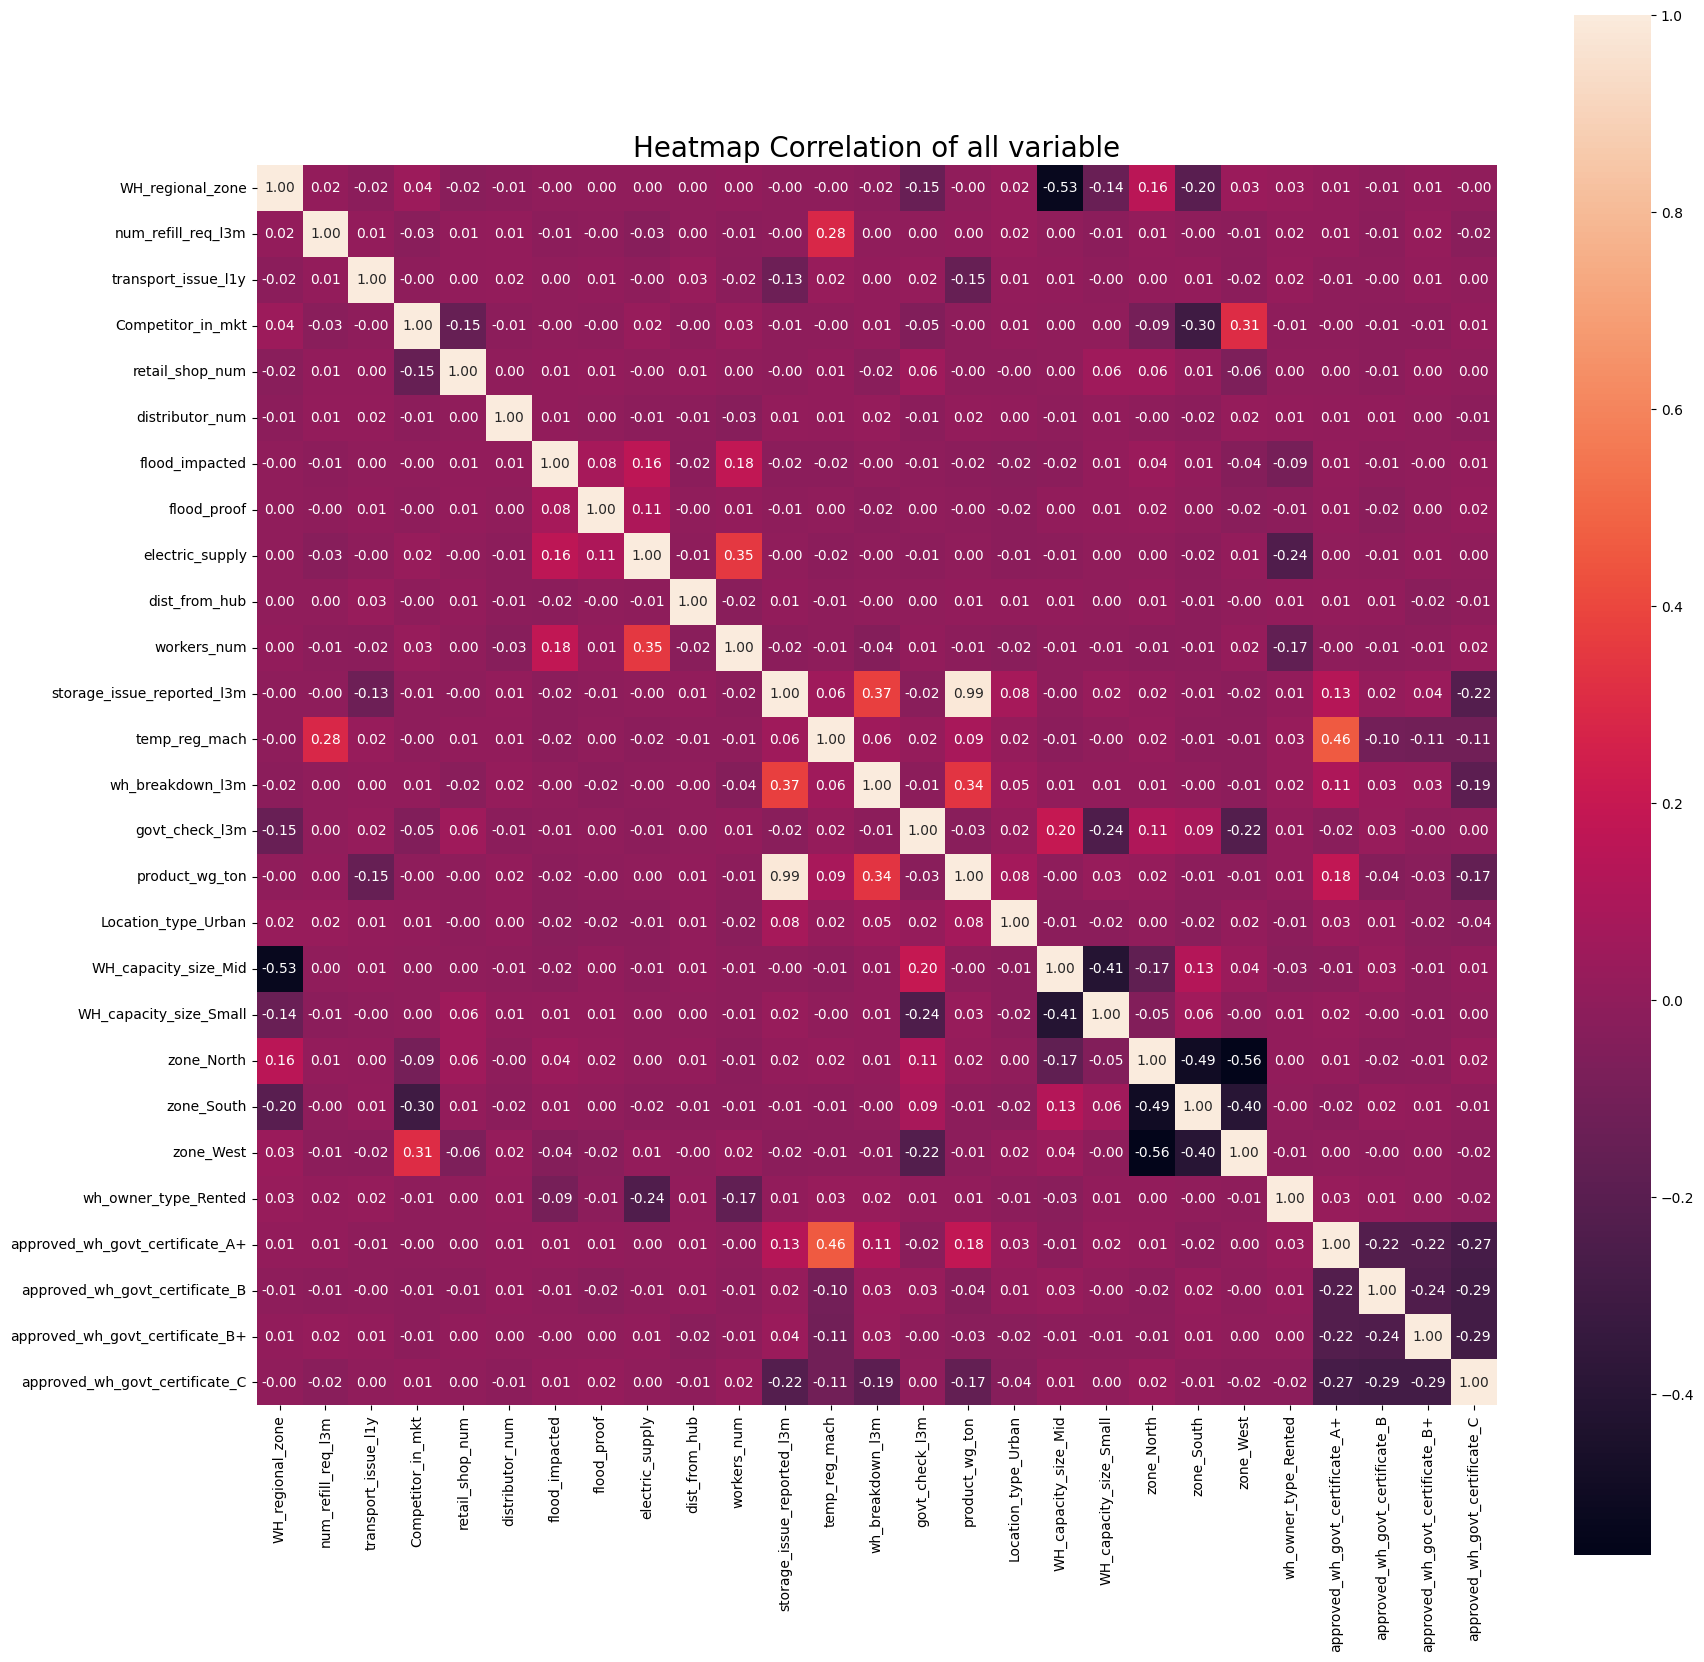

In [111]:
plt.figure(figsize=(20,20))
ax = sns.heatmap(te1.corr(),cbar=True, annot=True, square=True, fmt='.2f',annot_kws={'size':10})
plt.title('Heatmap Correlation of all variable',fontsize=20, fontweight=100)#title with fontsize 20
plt.show()

In [112]:
# checking outliers

In [113]:
te1.describe()

,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
count,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
mean,4.226081,4.007235,0.765600,3.106167,4980.695424,42.128052,0.104178,0.049919,0.657262,163.899982,29.010528,17.085549,0.298426,3.477302,18.892205,22052.334599,0.084645,0.399891,0.197685,0.410382,0.257009,0.313619,0.446735,0.174896,0.189727,0.191897,0.257913
std,1.679417,2.604325,1.187567,1.128396,1049.617325,15.959934,0.305519,0.217797,0.474668,62.544704,7.697959,9.206551,0.457609,1.700717,8.716737,11645.738485,0.278377,0.489920,0.398289,0.491947,0.437024,0.464005,0.497200,0.379912,0.392120,0.393828,0.437525
min,1.000000,0.000000,0.000000,1.000000,1953.000000,15.000000,0.000000,0.000000,0.000000,55.000000,10.000000,0.000000,0.000000,0.000000,1.000000,2065.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,0.000000,2.000000,4310.000000,28.000000,0.000000,0.000000,0.000000,110.000000,24.000000,10.000000,0.000000,2.000000,11.000000,12143.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,4.000000,0.000000,3.000000,4863.000000,42.000000,0.000000,0.000000,1.000000,165.000000,28.000000,17.000000,0.000000,3.000000,21.000000,22099.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,6.000000,1.000000,4.000000,5492.000000,56.000000,0.000000,0.000000,1.000000,218.000000,33.000000,24.000000,1.000000,5.000000,26.000000,30099.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,6.000000,8.000000,5.000000,9.000000,10846.000000,70.000000,1.000000,1.000000,1.000000,271.000000,98.000000,39.000000,1.000000,6.000000,32.000000,55144.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


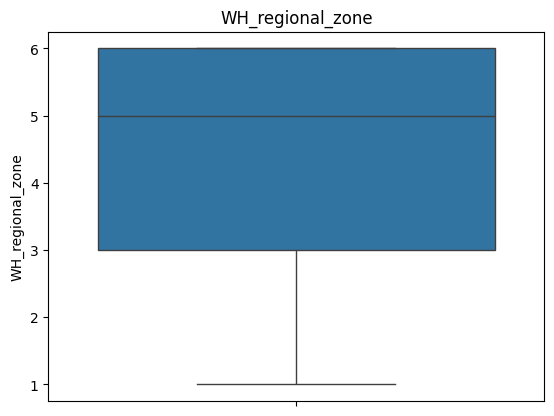

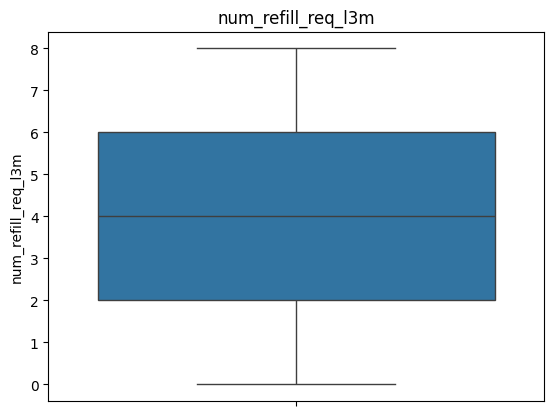

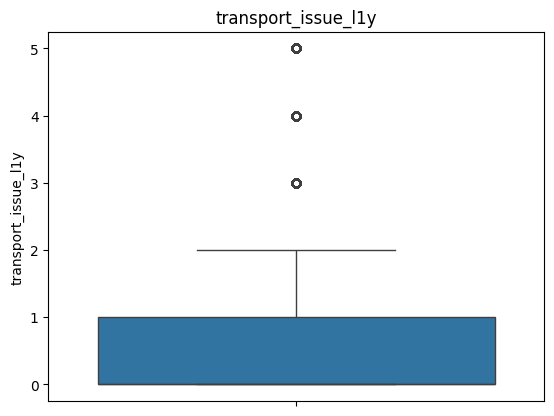

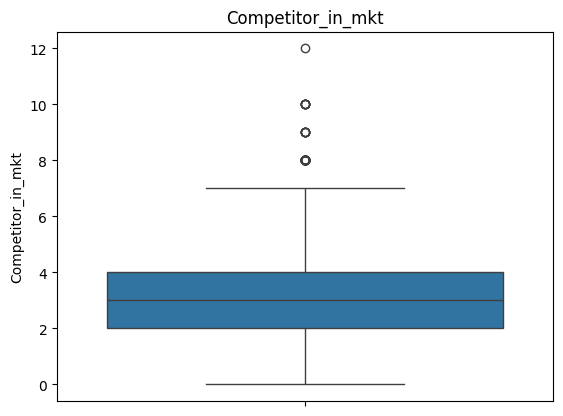

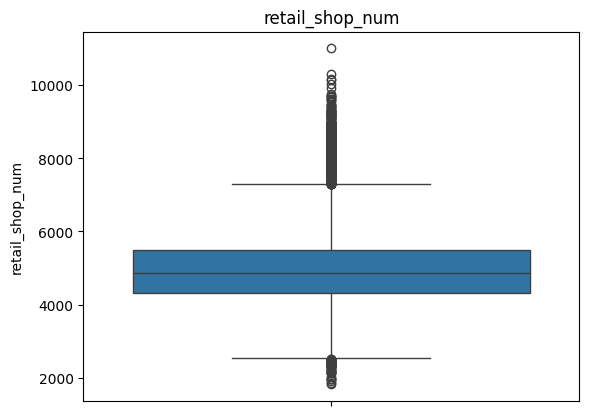

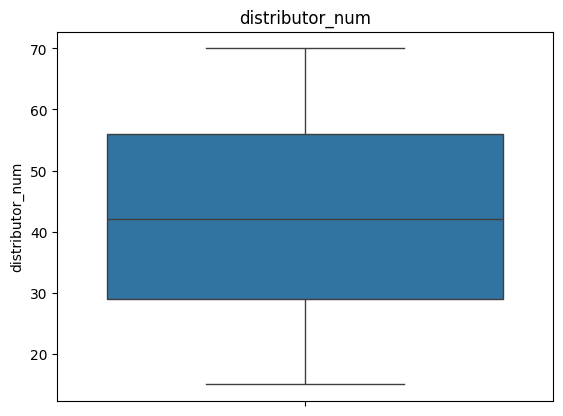

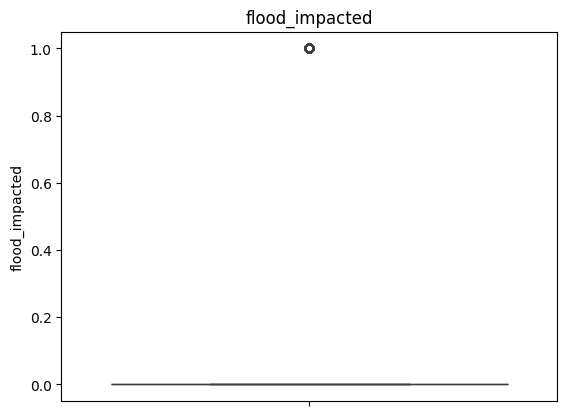

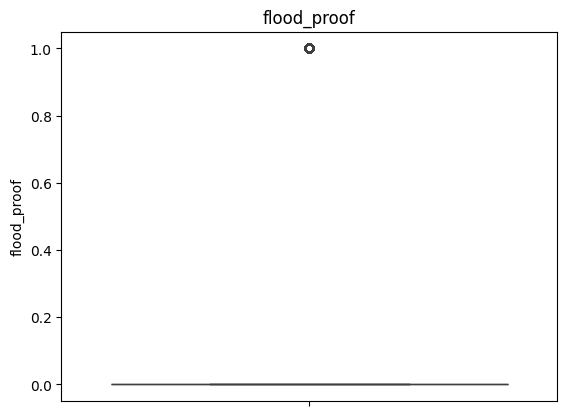

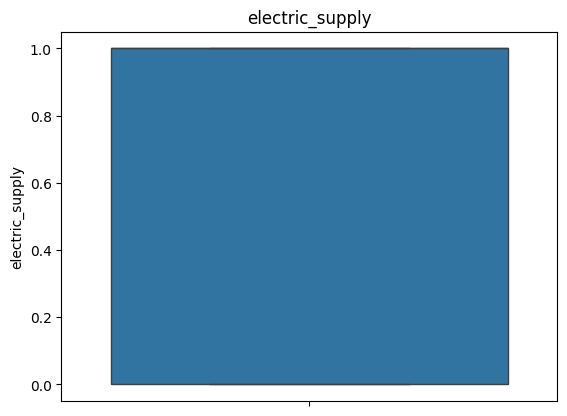

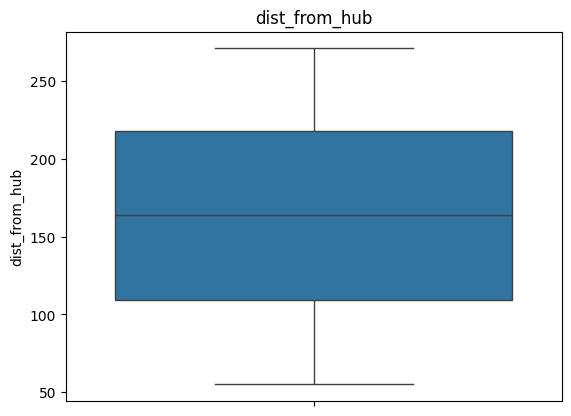

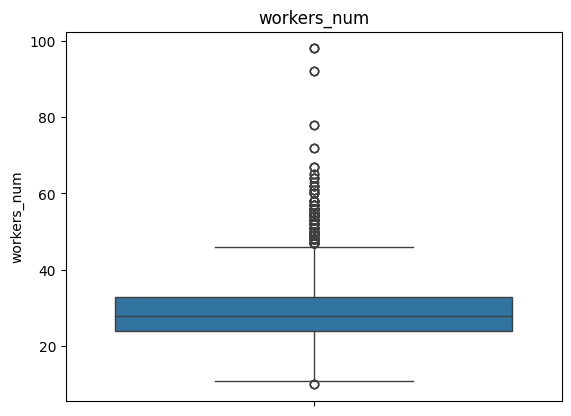

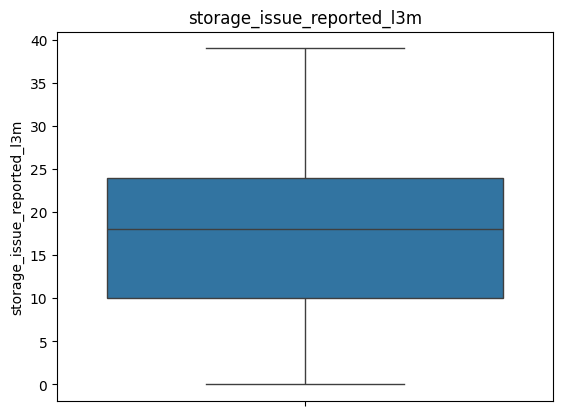

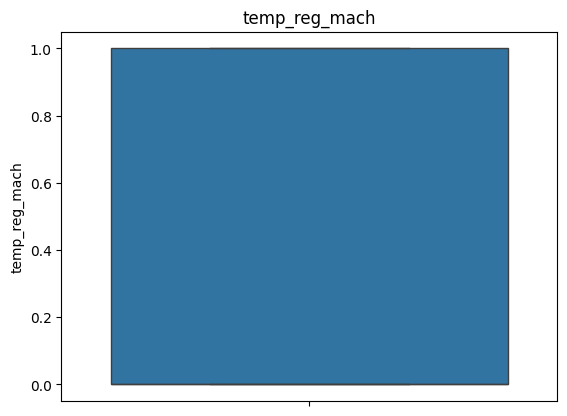

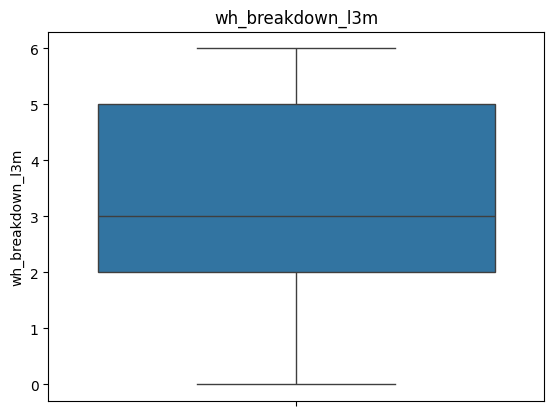

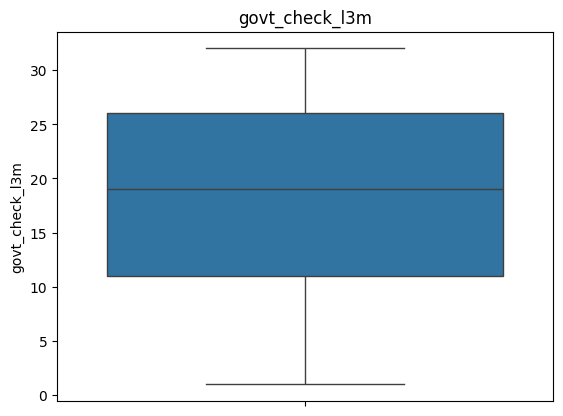

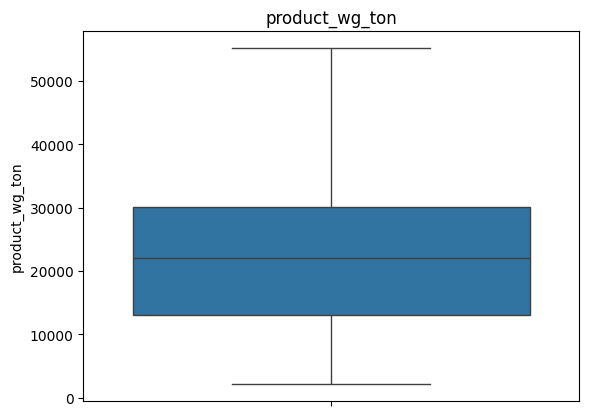

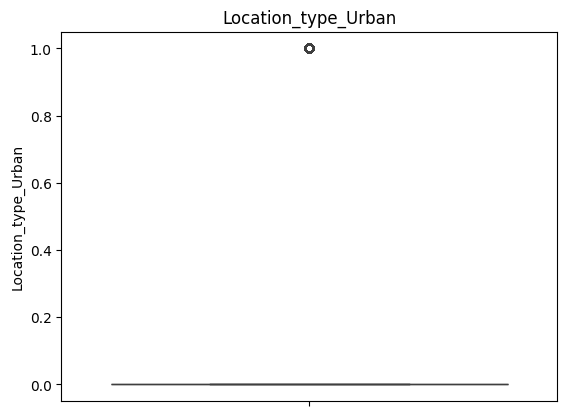

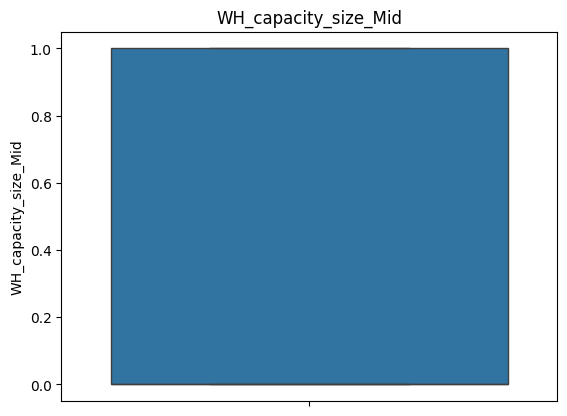

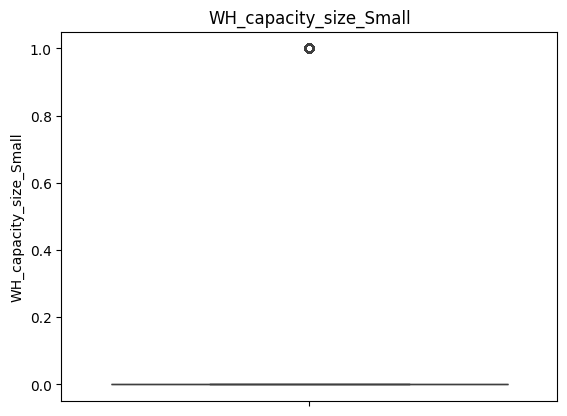

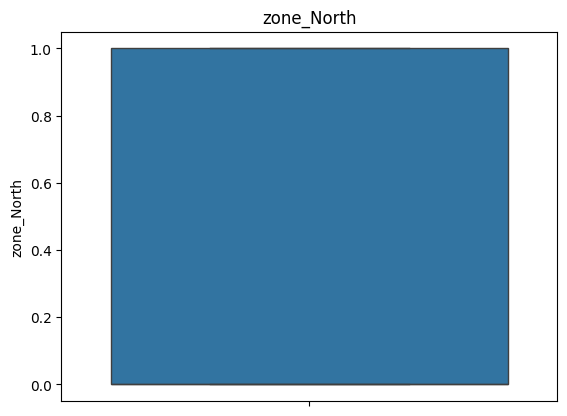

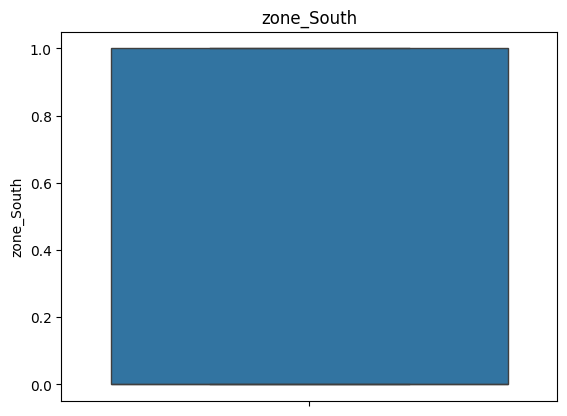

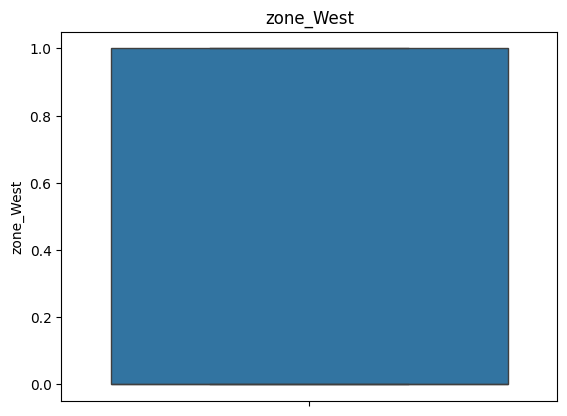

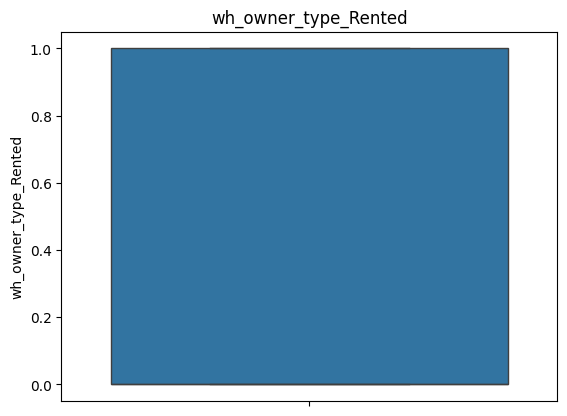

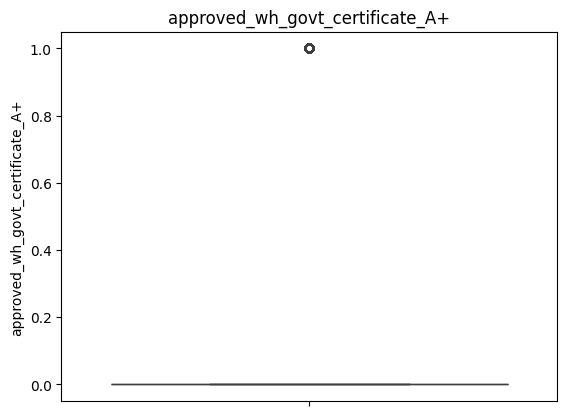

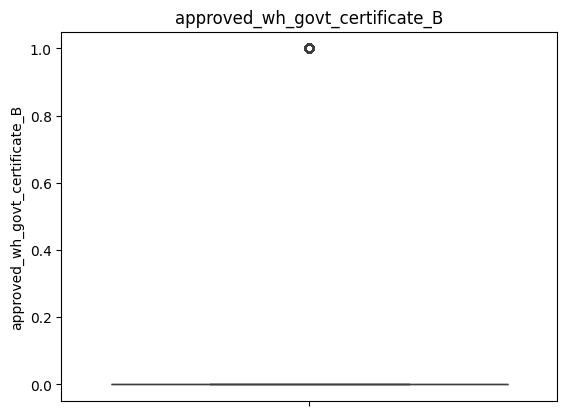

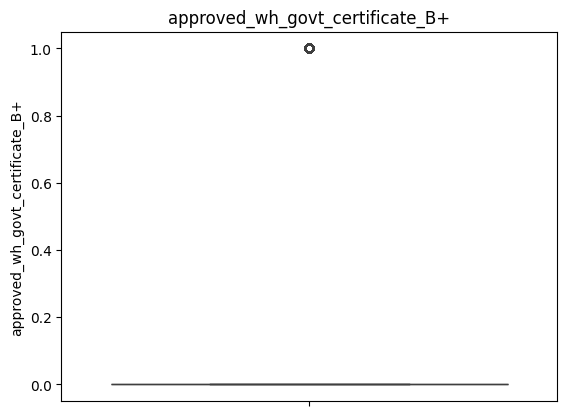

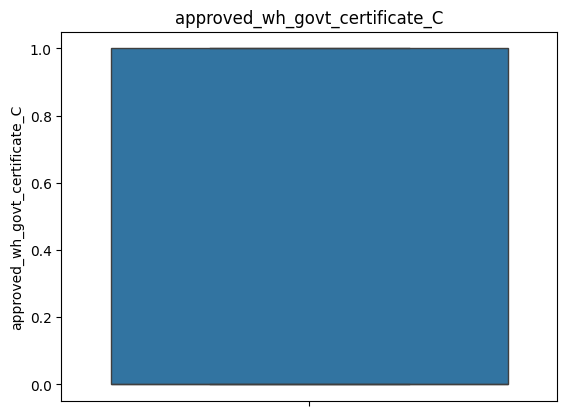

In [114]:
for i in te1.columns:
    sns.boxplot(df1[i])
    plt.title(i)
    plt.show()

In [115]:
# splitting of dependent variables and independent variable

In [116]:
x = te1.drop(['product_wg_ton'],axis=1)

In [117]:
y = te1['product_wg_ton']

In [118]:
# RandomForest

In [123]:
from sklearn.ensemble import RandomForestRegressor

In [124]:
random_forest = RandomForestRegressor(random_state=42)
random_forest.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [128]:
y_pred = random_forest.predict(x)

#Evaluate train and test dataset
model_mae, model_rmse, model_r2 = evaluate_model(y, y_pred)

print('Random Forest Regressor Model for Test set')
print('- Root Mean Squared Error:{:.4f}'.format(model_rmse))
print('- Mean Absolute Error:{:.4f}'.format(model_mae))
print('- R2 Score: {:.4f}'.format(model_r2))

Random Forest Regressor Model for Test set
- Root Mean Squared Error:375.0149
- Mean Absolute Error:271.9550
- R2 Score: 0.9990
